# 反向扩散采样的数值分析
## —— 后向误差分析、稳定性、误差预算与少步采样

**作者**：牛昱琛　**学号**：253108120111　（单人独立完成）
**课程**：《人工智能数理基础（高级）》开放课题 · 方向 **SC4AI**
**日期**：2026 年 5 月

---

> **摘要**　扩散模型的生成过程可以写成一条反向时间的随机微分方程（SDE），或与之同分布的概率流常微分方程（ODE），因此采样本质上是在数值求解一条微分方程。本文沿这一视角，用数值分析的方法考察反向采样的误差与稳定性。当数据取各向同性高斯时，反向过程是线性 SDE，它的各阶矩满足闭式的确定性递推；这给出一组解析参照值，可以用来逐一检验下面的结论。具体地：(i) 用后向误差分析（修正方程）推出 Euler–Maruyama 采样在生成分布方差上的领头阶 $O(h)$ 偏差及其系数，并用 Richardson 外推独立核对，两者相对误差约 $7.5\times10^{-6}$；(ii) 指出本问题属于加性噪声，此时 EM 的强收敛阶为 $1$，而不是乘性噪声下常说的 $1/2$；(iii) 用显式 Euler 的绝对稳定域解释采样步长的上界 $h\le 2/a(t)$；(iv) 给出半隐式/指数积分器以及概率流 ODE 的闭式解 $x\propto\sqrt{v}$，并比较少步采样；(v) 把总采样误差拆成分数、离散、先验三部分，并用 Fokker–Planck 残差诊断 score 的质量，再在二维高斯混合（非线性 score）上验证这一分解的推广性；(vi) 把分析迁移到训练得到的网络 score 上，定量考察离散误差与网络逼近误差的交叉。全部实验在二维以内、单机分钟级完成（代码同时支持 Apple Silicon 的 MPS 与 CPU，网络实验默认用 CPU 以保证逐位可复现），每条解析结论都在对应代码单元里用定量断言与解析参照对照。

## Part 0　引言

### 0.1 背景与计算难点
扩散模型是目前图像、音频、分子等生成任务中的主流方法，它由一个前向加噪过程（把数据逐步变成噪声）和一个反向去噪过程（把噪声逐步还原成数据）构成。Song 等人（2021）指出，二者都可写成连续时间的 SDE。前向过程为

$$\mathrm{d}X_t = -\tfrac12\beta(t)X_t\,\mathrm{d}t + \sqrt{\beta(t)}\,\mathrm{d}W_t,\qquad t\in(0,1],$$

反向（生成）过程则由 Anderson（1982）的时间反演给出。在实践中，最耗算力、也最依赖经验的一步是反向采样：步数取多少、用哪种离散格式、噪声调度怎么选、少步采样为什么会变糊，这些问题本质上属于数值分析的范畴——相容性、收敛阶、稳定性、刚性、后向误差分析正是用来回答它们的工具。

### 0.2 研究视角
本文的出发点是把反向采样看成"数值求解反向时间 SDE 或概率流 ODE"，用科学计算的方法来分析这一过程。为此选取数据为高斯的设定：此时反向过程是线性 SDE，均值与方差都有闭式表达，于是"EM 实际在采哪条被修正的分布""偏差有多大""何时会失稳"这些问题都能与解析值直接对照，而不必停留在经验调参上。这也对应课程 SC4AI（科学计算支撑人工智能）的方向。

### 0.3 与课程内容的衔接
- Lect6（扩散模型与反向 SDE）：本文以其中的 VP-SDE、去噪分数匹配（DSM）和 Swiss-Roll 例子为基线并在其上展开。
- Lect5（SGD 与修正方程）：本文用到的"采样修正方程"与该讲的"SGD 修正方程"是同一种后向误差分析方法，二者都把一个离散迭代看成某条被修正的微分方程的数值格式。

### 0.4 主要工作
1. 用后向误差分析推出反向 EM 在生成分布方差上的领头阶 $O(h)$ 偏差系数 $c$，并用 Richardson 外推独立核对（相对误差约 $7.5\times10^{-6}$，见实验②）。
2. 说明本问题属于加性噪声，此时 EM 的强阶与弱阶都为 $1$；以共享布朗路径数值验证，并与乘性噪声（强阶 $1/2$）对照（实验③）。
3. 用显式 Euler 的绝对稳定域给出步长上界 $h\le 2/a(t)$，并指出最不稳定的时刻在 $t\approx1$（实验④）。
4. 给出半隐式/指数积分器（降低误差常数）与概率流 ODE 的闭式解 $x(t)=\sqrt{v(t)/v(1)}\,x(1)$，并比较少步采样的 NFE–质量关系（实验⑤⑥）。
5. 把总采样误差拆成分数、离散、先验三部分分别度量（实验⑧），并用 Fokker–Planck 残差诊断 score 质量（实验⑨）。
6. 把分析迁移到训练得到的网络 score，定量考察离散误差与网络逼近误差的交叉（实验⑩）。
7. 在二维高斯混合（非线性 score）上重做误差三分解，验证该框架的推广性（实验⑪）。

### 0.5 全文结构
Part I 给出理论基础；Part II 讨论误差与收敛（实验①②③）；Part III 讨论稳定性与刚性（实验④）；Part IV 给出改进的采样器（实验⑤⑥⑦）；Part V 是误差预算与 score 诊断（实验⑧⑨⑩⑪）；Part VI 为总结。所有数值函数集中在下一节"核心数值库"单元中，本 notebook 单文件即可运行。

## 核心数值库

下面这个代码单元集中定义全文用到的所有数值函数：噪声调度与边缘分布、解析 score（高斯与高斯混合）、反向动力学与精确方差、Euler–Maruyama 与半隐式/概率流采样器、各类度量（Bures-$W_2$、矩误差、sliced-Wasserstein）、刚性与稳定域、Fokker–Planck 残差，以及一个用于网络迁移实验的小 score 网络。它不依赖任何外部文件，使本 notebook 单文件即可运行；后续各实验单元通过命名空间 `dna` 调用其中的函数（`dna` 即本单元所在的命名空间）。

In [1]:
"""diffusion_na —— 反向扩散采样的数值分析 · 核心库（核心解析公式均有数值核验）。

统一时间约定（全程严格一致，已数值核验）
------------------------------------------------
- VP 前向 SDE:  dX = -1/2 beta(t) X dt + sqrt(beta(t)) dW,  t in (0,1].
- beta(t) = 0.1 + 19.9 t,  B(t) = ∫_0^t beta = 0.1 t + 9.95 t^2.
- 数据 X0 ~ N(0, s0^2 I)，默认 s0 = DATA_STD = 0.5（s0 = 1 退化，禁用）。
- 边缘 v(t) = 1 + (s0^2 - 1) e^{-B(t)}，精确 score  s*(x,t) = -x / v(t)（线性）。
- 反向漂移系数 a(t) = beta(t) (1/v(t) - 1/2) > 0。
- 反向采样网格 t_n: 1 -> eps，正步长 h = t_n - t_{n+1} > 0。
    EM 一步:        x_{n+1} = (1 - a(t_n) h) x_n + sqrt(beta(t_n) h) z
    方差递推:        V_{n+1} = (1 - a(t_n) h)^2 V_n + beta(t_n) h
- 反向时间 tau = 1 - t:  dV/dtau = -2 a(1-tau) V + beta(1-tau)  （★ 含因子 2）
- 概率流 ODE:  前向 f_pf(t,x) = 1/2 beta(t) (1/v(t) - 1) x；
    高斯闭式精确解  x(t) = sqrt(v(t)/v(1)) x(1)。
"""

import numpy as np
from scipy.integrate import solve_ivp
from scipy.special import logsumexp

BETA_MIN = 0.1
BETA_MAX = 20.0
DATA_STD = 0.5
EPS = 1e-3
SEED = 2026

_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz  # numpy>=2.0 改名


# ----------------------------------------------------------------------
# 1. 调度、边缘分布与精确 score
# ----------------------------------------------------------------------
def beta(t):
    return BETA_MIN + (BETA_MAX - BETA_MIN) * np.asarray(t, dtype=float)


def int_beta(t):
    """B(t) = ∫_0^t beta(s) ds."""
    t = np.asarray(t, dtype=float)
    return BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t ** 2


def alpha(t):
    """转移核均值尺度 e^{-B/2}."""
    return np.exp(-0.5 * int_beta(t))


def sigma2(t):
    """转移核方差 1 - e^{-B}（数值稳定）."""
    return -np.expm1(-int_beta(t))


def marginal_var(t, s0=DATA_STD):
    """各向同性高斯数据的边缘方差 v(t)."""
    return 1.0 + (s0 ** 2 - 1.0) * np.exp(-int_beta(t))


def _log_marginal_gaussian(x, t, s0=DATA_STD):
    x = np.asarray(x, dtype=float)
    v = marginal_var(t, s0)
    d = x.size
    return -0.5 * np.sum(x ** 2) / v - 0.5 * d * np.log(2 * np.pi * v)


def exact_score_gaussian(x, t, s0=DATA_STD):
    """∇ log p(x,t) = -x / v(t)（线性）."""
    return -np.asarray(x, dtype=float) / marginal_var(t, s0)


# ----------------------------------------------------------------------
# 2. 高斯混合的闭式边缘与 score（批量 [N,d] -> [N,d]）
# ----------------------------------------------------------------------
def _component_var(t, s0):
    return alpha(t) ** 2 * s0 ** 2 + sigma2(t)


def gmm_log_marginal(x, t, means, weights, s0=0.4):
    x = np.atleast_2d(np.asarray(x, float))            # [N,d]
    means = np.asarray(means, float)                   # [K,d]
    w = np.asarray(weights, float)                     # [K]
    vt = _component_var(t, s0)
    d = x.shape[1]
    mu = alpha(t) * means                              # [K,d]
    sq = np.sum((x[:, None, :] - mu[None, :, :]) ** 2, axis=-1)  # [N,K]
    logc = -0.5 * d * np.log(2 * np.pi * vt)
    logp_k = logc - 0.5 * sq / vt                      # [N,K]
    return logsumexp(logp_k, b=w[None, :], axis=1)     # [N]


def exact_score_gmm(x, t, means, weights, s0=0.4):
    x = np.atleast_2d(np.asarray(x, float))            # [N,d]
    means = np.asarray(means, float)                   # [K,d]
    w = np.asarray(weights, float)                     # [K]
    vt = _component_var(t, s0)
    mu = alpha(t) * means                              # [K,d]
    diff = mu[None, :, :] - x[:, None, :]              # [N,K,d]
    sq = np.sum(diff ** 2, axis=-1)                    # [N,K]
    logp = np.log(w)[None, :] - 0.5 * sq / vt          # [N,K]
    logp = logp - logp.max(axis=1, keepdims=True)
    r = np.exp(logp)
    r = r / r.sum(axis=1, keepdims=True)               # 后验权重 [N,K]
    return np.sum(r[:, :, None] * diff / vt, axis=1)   # [N,d]


# ----------------------------------------------------------------------
# 3. 反向动力学与精确方差参照（含因子 2）
# ----------------------------------------------------------------------
def reverse_drift_coeff(t, s0=DATA_STD):
    """a(t) = beta(t)(1/v(t) - 1/2)（s0<1 时 v(t)<1 => a(t)>0 全程成立）。"""
    return beta(t) * (1.0 / marginal_var(t, s0) - 0.5)


def reverse_drift_coeff_prime(t, s0=DATA_STD):
    """a'(t) 闭式导数（供解析 V''）：a=beta(1/v-1/2)，beta'=BMAX-BMIN，v'=-(v-1)beta。"""
    v = marginal_var(t, s0)
    b = beta(t)
    bp = BETA_MAX - BETA_MIN
    return bp * (1.0 / v - 0.5) + b ** 2 * (v - 1.0) / v ** 2


def reverse_variance_exact(t_end, s0=DATA_STD, t_start=1.0, V_start=None, dense=False):
    """高精度求解反向方差 ODE dV/dtau = -2 a V + beta（含因子 2）。

    V_start=None 时取真值起点 marginal_var(t_start)（隔离离散误差）。
    dense=True 返回 OdeSolution（供取二阶导）。
    """
    if V_start is None:
        V_start = marginal_var(t_start, s0)

    def rhs(tau, V):
        t = t_start - tau
        a = reverse_drift_coeff(t, s0)
        return [-2.0 * a * V[0] + beta(t)]            # ★ 因子 2

    tau_end = t_start - t_end
    sol = solve_ivp(rhs, [0.0, tau_end], [float(V_start)],
                    rtol=1e-10, atol=1e-10, dense_output=True)
    return sol if dense else float(sol.y[0, -1])


# ----------------------------------------------------------------------
# 4. 反向 EM 方差确定性递推 + 随机采样器（互校）
# ----------------------------------------------------------------------
def em_variance_recursion(N, eps=EPS, s0=DATA_STD, t_start=1.0, V_start=1.0):
    ts = np.linspace(t_start, eps, N + 1)
    V = float(V_start)
    for i in range(N):
        t = ts[i]
        h = ts[i] - ts[i + 1]
        a = reverse_drift_coeff(t, s0)
        V = (1.0 - a * h) ** 2 * V + beta(t) * h
    return V


def em_sample(N, n_samples=10000, eps=EPS, s0=DATA_STD, dim=1, seed=0, x_start=None):
    rng = np.random.default_rng(seed)
    ts = np.linspace(1.0, eps, N + 1)
    if x_start is None:
        x = rng.standard_normal((n_samples, dim))      # 先验 N(0,I)
    else:
        x = np.array(x_start, dtype=float)
    for i in range(N):
        t = ts[i]
        h = ts[i] - ts[i + 1]
        a = reverse_drift_coeff(t, s0)
        x = (1.0 - a * h) * x + np.sqrt(beta(t) * h) * rng.standard_normal(x.shape)
    return x


# ----------------------------------------------------------------------
# 5. O(h) 偏差律与修正方程系数（后向误差分析）
# ----------------------------------------------------------------------
def bias_coeff_empirical(eps=EPS, s0=DATA_STD, Ns=(800, 1600, 3200, 6400)):
    """Richardson 外推得 (V_N - target)/h 在 h->0 的极限 c_emp."""
    target = reverse_variance_exact(eps, s0=s0, V_start=marginal_var(1.0, s0))
    Vs = np.array([em_variance_recursion(N, eps=eps, s0=s0, V_start=marginal_var(1.0, s0))
                   for N in Ns])
    hs = (1.0 - eps) / np.array(Ns, dtype=float)
    ratios = (Vs - target) / hs
    A = np.vstack([np.ones_like(hs), hs]).T
    return float(np.linalg.lstsq(A, ratios, rcond=None)[0][0])


def bias_coeff_theory(eps=EPS, s0=DATA_STD, M=40000):
    """闭式领头阶偏差系数 c = ∫ Phi(T,s)[a^2 V - 1/2 V''] ds，Phi=exp(∫ -2a)."""
    T = 1.0 - eps
    taus = np.linspace(0.0, T, M)
    t = 1.0 - taus
    a = reverse_drift_coeff(t, s0)
    sol = reverse_variance_exact(eps, s0=s0, V_start=marginal_var(1.0, s0), dense=True)
    V = sol.sol(taus)[0]
    # 解析 V''(τ)：V'=F=-2aV+β ⇒ V''=dF/dτ=2a'(1-τ)V - 2a(1-τ)F - β'(1-τ)（机器精度，与差分步长无关）
    F = -2.0 * a * V + beta(t)
    ap = reverse_drift_coeff_prime(t, s0)
    bp = BETA_MAX - BETA_MIN
    Vpp = 2.0 * ap * V - 2.0 * a * F - bp
    H = a ** 2 * V - 0.5 * Vpp                          # 修正项（含离散耦合 G=a^2 V）
    cum = np.concatenate([[0.0], np.cumsum(0.5 * (a[1:] + a[:-1]) * np.diff(taus))])  # ∫_0^s a
    Phi = np.exp(-2.0 * (cum[-1] - cum))                # exp(∫_s^T -2a)
    return float(_trapz(Phi * H, taus))


# ----------------------------------------------------------------------
# 6. 改进采样器：半隐式/指数处理线性漂移 + 概率流 ODE
# ----------------------------------------------------------------------
def semiimplicit_variance_recursion(N, eps=EPS, s0=DATA_STD, t_start=1.0, V_start=1.0):
    """每步对线性漂移做常系数 OU 精确步（降低误差常数，整体仍 O(h)）。"""
    ts = np.linspace(t_start, eps, N + 1)
    V = float(V_start)
    for i in range(N):
        t = ts[i]
        h = ts[i] - ts[i + 1]
        a = reverse_drift_coeff(t, s0)
        decay = np.exp(-a * h)
        if abs(a) > 1e-8:
            noise = beta(t) * (1.0 - np.exp(-2.0 * a * h)) / (2.0 * a)
        else:
            noise = beta(t) * h
        V = decay ** 2 * V + noise
    return V


def pf_ode_exact(x_start, eps=EPS, s0=DATA_STD, t_start=1.0):
    """高斯概率流 ODE 闭式精确解 x(eps) = sqrt(v(eps)/v(1)) x(1)（机器精度参照）。"""
    return float(np.sqrt(marginal_var(eps, s0) / marginal_var(t_start, s0)) * x_start)


def pf_ode_drift(t, x, s0=DATA_STD):
    """前向概率流漂移 f_pf = 1/2 beta (1/v - 1) x."""
    return 0.5 * beta(t) * (1.0 / marginal_var(t, s0) - 1.0) * np.asarray(x, float)


def pf_ode_sample(N, method, x_start, eps=EPS, s0=DATA_STD):
    """反向积分概率流 ODE（t: 1 -> eps，正步长 h）。method ∈ {'euler','heun'}."""
    ts = np.linspace(1.0, eps, N + 1)
    x = np.asarray(x_start, dtype=float)
    for i in range(N):
        t = ts[i]
        h = ts[i] - ts[i + 1]
        f1 = pf_ode_drift(t, x, s0)
        if method == "euler":
            x = x - h * f1
        elif method == "heun":
            xp = x - h * f1
            f2 = pf_ode_drift(ts[i + 1], xp, s0)
            x = x - 0.5 * h * (f1 + f2)
        else:
            raise ValueError(f"unknown method: {method}")
    return float(x) if np.ndim(x) == 0 else x


# ----------------------------------------------------------------------
# 6b. 通用 score-based 反向采样器（解析或网络 score 均可，用于多维实验）
# ----------------------------------------------------------------------
def reverse_sample(score_fn, N, method="em", x0=None, n_samples=1000, dim=2,
                   eps=EPS, seed=0, return_nfe=False):
    """反向积分（t:1->eps，正步长 h）。score_fn(x[M,d], t) -> [M,d]。

    method:
      'em'       反向 SDE Euler-Maruyama:  x += h(½β x + β s) + sqrt(βh) z
      'pf_euler' 概率流 ODE 反向 Euler:     x += h(½β x + ½β s)
      'pf_heun'  概率流 ODE 反向 Heun(2阶): 两段平均
    与解析采样器一致（s=-x/v 时 'em' 化为 (1-ah)x+√(βh)z）。
    """
    rng = np.random.default_rng(seed)
    ts = np.linspace(1.0, eps, N + 1)
    if x0 is None:
        x = rng.standard_normal((n_samples, dim))
    else:
        x = np.asarray(x0, dtype=float).copy()
    nfe = 0
    for i in range(N):
        t = ts[i]
        h = ts[i] - ts[i + 1]
        b = beta(t)
        s = score_fn(x, t); nfe += 1
        if method == "em":
            x = x + h * (0.5 * b * x + b * s) + np.sqrt(b * h) * rng.standard_normal(x.shape)
        elif method == "pf_euler":
            x = x + h * (0.5 * b * x + 0.5 * b * s)
        elif method == "pf_heun":
            x1 = x + h * (0.5 * b * x + 0.5 * b * s)
            t2 = ts[i + 1]; b2 = beta(t2)
            s2 = score_fn(x1, t2); nfe += 1
            x = x + 0.5 * h * ((0.5 * b * x + 0.5 * b * s) + (0.5 * b2 * x1 + 0.5 * b2 * s2))
        else:
            raise ValueError(f"unknown method: {method}")
    return (x, nfe) if return_nfe else x


# ----------------------------------------------------------------------
# 7. 度量：Bures-W2、矩误差、sliced-Wasserstein、energy distance
# ----------------------------------------------------------------------
def _psd_sqrt(C):
    C = 0.5 * (C + C.T)
    w, Q = np.linalg.eigh(C)
    w = np.clip(w, 0.0, None)
    return (Q * np.sqrt(w)) @ Q.T


def bures_w2(m1, C1, m2, C2):
    """两高斯间 2-Wasserstein 距离（闭式 Bures，含对称化+特征值截断）。"""
    m1, m2 = np.atleast_1d(m1).astype(float), np.atleast_1d(m2).astype(float)
    C1, C2 = np.atleast_2d(C1).astype(float), np.atleast_2d(C2).astype(float)
    s1 = _psd_sqrt(C1)
    cross = _psd_sqrt(s1 @ C2 @ s1)
    bures = np.trace(C1 + C2 - 2.0 * cross)
    return float(np.sqrt(max(np.sum((m1 - m2) ** 2) + float(bures), 0.0)))


def moment_error(samples, m_true, v_true):
    """前两阶矩误差（均值 + 方差），逐维平均。"""
    samples = np.atleast_2d(samples)
    return float(np.abs(samples.mean(0) - m_true).mean()
                 + np.abs(samples.var(0) - v_true).mean())


def sliced_wasserstein(X, Y, n_proj=200, seed=0):
    """2-D 点云主指标：sliced-Wasserstein-1（O(n log n)）。"""
    X = np.atleast_2d(X)
    Y = np.atleast_2d(Y)
    rng = np.random.default_rng(seed)
    d = X.shape[1]
    th = rng.standard_normal((d, n_proj))
    th /= np.linalg.norm(th, axis=0, keepdims=True)
    px = np.sort(X @ th, axis=0)
    py = np.sort(Y @ th, axis=0)
    if px.shape[0] != py.shape[0]:
        m = min(px.shape[0], py.shape[0])
        q = np.linspace(0.0, 1.0, m)
        px = np.stack([np.quantile(px[:, j], q) for j in range(n_proj)], axis=1)
        py = np.stack([np.quantile(py[:, j], q) for j in range(n_proj)], axis=1)
    return float(np.mean(np.abs(px - py)))


def energy_distance(X, Y, max_n=512, seed=0):
    """辅助指标：energy distance；子采样 n<=max_n 避免 O(n^2) 内存。"""
    X = np.atleast_2d(X)
    Y = np.atleast_2d(Y)
    rng = np.random.default_rng(seed)
    if len(X) > max_n:
        X = X[rng.choice(len(X), max_n, replace=False)]
    if len(Y) > max_n:
        Y = Y[rng.choice(len(Y), max_n, replace=False)]

    def pd(A, B):
        return np.sqrt(((A[:, None, :] - B[None, :, :]) ** 2).sum(-1) + 1e-12).mean()

    return float(2 * pd(X, Y) - pd(X, X) - pd(Y, Y))


# ----------------------------------------------------------------------
# 8. 刚性与显式 Euler 稳定域
# ----------------------------------------------------------------------
def stiffness(t, s0=DATA_STD):
    """L(t) = |a(t)|（反向漂移 Jacobian 谱）。"""
    return np.abs(reverse_drift_coeff(t, s0))


def critical_dt(t, s0=DATA_STD):
    """显式 Euler 稳定步长界 2/|a(t)|。"""
    return 2.0 / np.abs(reverse_drift_coeff(t, s0))


def em_blows_up(N, eps=EPS, s0=DATA_STD, threshold=10.0):
    """N 太小（h 太大）时 |1-ah|>1 放大，方差爆/不收敛 -> True。"""
    V = em_variance_recursion(N, eps=eps, s0=s0, V_start=marginal_var(1.0, s0))
    target = marginal_var(eps, s0)
    return (not np.isfinite(V)) or (V > threshold * target) or (V < 0.0)


# ----------------------------------------------------------------------
# 9. Fokker–Planck（log-FPE）残差算子（torch autograd, float64 CPU）
# ----------------------------------------------------------------------
def fpe_residual_gaussian(x, t, s0=DATA_STD, perturb=0.0):
    """log-FPE 残差  ∂_t log p - 1/2 beta [ d + x·s + ||s||^2 + ∇·s ]，s=∇log p。

    解析高斯 + 真值 score (perturb=0) 时应 ≈ 0；perturb≠0 残差随之增大。
    """
    import torch

    x = np.atleast_2d(np.asarray(x, float))
    N, d = x.shape
    xt = torch.tensor(x, dtype=torch.float64, requires_grad=True)
    tt = torch.full((N, 1), float(t), dtype=torch.float64, requires_grad=True)
    Bt = BETA_MIN * tt + 0.5 * (BETA_MAX - BETA_MIN) * tt ** 2     # [N,1]
    v = 1.0 + (s0 ** 2 - 1.0) * torch.exp(-Bt)                     # [N,1]
    logp = (-0.5 * (xt ** 2).sum(1, keepdim=True) / v
            - 0.5 * d * torch.log(2 * np.pi * v))                 # [N,1]
    dlogp_dt = torch.autograd.grad(logp.sum(), tt, create_graph=True)[0].squeeze(1)  # [N]
    s = -xt / v + perturb                                         # [N,d]
    div_s = torch.zeros(N, dtype=torch.float64)
    for i in range(d):
        gi = torch.autograd.grad(s[:, i].sum(), xt, create_graph=True)[0][:, i]
        div_s = div_s + gi
    xs = (xt * s).sum(1)
    s2 = (s ** 2).sum(1)
    beta_t = BETA_MIN + (BETA_MAX - BETA_MIN) * float(t)
    res = dlogp_dt - 0.5 * beta_t * (d + xs + s2 + div_s)
    return res.detach().numpy()


# ----------------------------------------------------------------------
# 10. 小 score 网络与 DSM 训练（网络迁移实验用；支持 MPS）
# ----------------------------------------------------------------------
def _make_score_net(dim=1, hidden=64):
    import torch.nn as nn

    class ScoreNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(dim + 1, hidden), nn.LogSigmoid(),
                nn.Linear(hidden, hidden), nn.LogSigmoid(),
                nn.Linear(hidden, hidden), nn.LogSigmoid(),
                nn.Linear(hidden, dim),
            )

        def forward(self, x, t):
            return self.net(__import__("torch").cat([x, t], dim=1))

    return ScoreNet()


def _dsm_train(sampler, dim, n_iters, device, seed, lr, batch, hidden):
    import torch

    torch.manual_seed(seed)
    dev = torch.device(device)
    net = _make_score_net(dim=dim, hidden=hidden).to(dev)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    g = torch.Generator().manual_seed(seed)
    losses = []
    for _ in range(n_iters):
        x0 = sampler(batch, g)                                    # [batch,dim] cpu f32
        t = torch.rand(batch, 1, generator=g) * (1 - 2e-3) + 1e-3
        Bt = BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t ** 2
        a_t = torch.exp(-0.5 * Bt)
        var_t = -torch.expm1(-Bt)
        noise = torch.randn(batch, dim, generator=g)
        xt = a_t * x0 + torch.sqrt(var_t) * noise
        target = -noise / torch.sqrt(var_t)                       # (mu - xt)/var
        xt, t, target, var_t = (z.to(dev) for z in (xt, t, target, var_t))
        s = net(xt, t)
        loss = (var_t * (s - target) ** 2).mean()                 # sigma^2-加权 DSM
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(float(loss.item()))
    net.eval()
    net.losses_ = losses
    return net


def train_score_net_gaussian(s0=DATA_STD, n_iters=4000, device="cpu", seed=0,
                             dim=1, lr=3e-3, batch=512, hidden=64):
    import torch
    return _dsm_train(lambda b, g: s0 * torch.randn(b, dim, generator=g),
                      dim, n_iters, device, seed, lr, batch, hidden)


def make_swiss_roll_2d(n, seed=0, scale=0.1):
    from sklearn.datasets import make_swiss_roll
    X, _ = make_swiss_roll(n, noise=1.0, random_state=seed)
    X = X[:, [0, 2]] * scale
    return X.astype(np.float32)


def train_score_net_data(X, n_iters=8000, device="cpu", seed=0,
                         lr=3e-3, batch=256, hidden=64):
    import torch
    Xt = torch.tensor(np.asarray(X, np.float32))
    dim = Xt.shape[1]

    def sampler(b, g):
        idx = torch.randint(0, Xt.shape[0], (b,), generator=g)
        return Xt[idx]

    return _dsm_train(sampler, dim, n_iters, device, seed, lr, batch, hidden)


def eval_score_net(net, x, t, device="cpu"):
    import torch
    dev = torch.device(device)
    x = torch.tensor(np.atleast_2d(np.asarray(x, float)), dtype=torch.float32, device=dev)
    tt = torch.full((x.shape[0], 1), float(t), dtype=torch.float32, device=dev)
    with torch.no_grad():
        s = net(x, tt).cpu().numpy()
    return s


def pick_device():
    """优先 MPS（Apple Silicon），否则 CPU。"""
    import torch
    return "mps" if torch.backends.mps.is_available() else "cpu"


# 将本单元定义的全部函数与常量收拢到命名空间 dna，供后续实验单元调用
import sys as _sys
dna = _sys.modules[__name__]
print("核心数值库就绪")

核心数值库就绪


In [2]:
# 环境与导入
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch

# 中文字体（macOS 自带优先）
_avail = {f.name for f in fm.fontManager.ttflist}
for _f in ['PingFang SC', 'Arial Unicode MS', 'Heiti TC', 'STHeiti', 'Songti SC', 'SimHei']:
    if _f in _avail:
        mpl.rcParams['font.sans-serif'] = [_f]
        break
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 110

os.makedirs('figures', exist_ok=True)
np.random.seed(dna.SEED)
torch.manual_seed(dna.SEED)

S0  = dna.DATA_STD     # 数据标准差 0.5
EPS = dna.EPS          # 采样终止时间 1e-3
# 代码 device-agnostic：MPS(Apple Silicon)/CPU 均可。为使网络实验逐位可复现，默认用 CPU
# （小网络、秒级）；启用 MPS 只需改为 DEVICE = dna.pick_device()。解析实验为 NumPy，与设备无关。
DEVICE = 'cpu'

print('网络实验 device =', DEVICE, '| 可用加速器 =', dna.pick_device(),
      '| torch', torch.__version__, '| mps', torch.backends.mps.is_available())
print('beta(0)=%.3f  beta(1)=%.3f  B(1)=%.4f' % (dna.beta(0.), dna.beta(1.), dna.int_beta(1.)))
print('v(eps)=%.5f  v(1)=%.5f' % (dna.marginal_var(EPS), dna.marginal_var(1.0)))
print('a(1)=%.4f  critical_dt(1)=2/a=%.4f' % (dna.reverse_drift_coeff(1.0), dna.critical_dt(1.0)))

网络实验 device = cpu | 可用加速器 = mps | torch 2.12.0 | mps True
beta(0)=0.100  beta(1)=20.000  B(1)=10.0500
v(eps)=0.25008  v(1)=0.99997
a(1)=10.0006  critical_dt(1)=2/a=0.2000


## Part I　理论基础

### §1 前向/反向 SDE、score 与去噪分数匹配

**前向 VP-SDE.** 取线性噪声调度 $\beta(t)=\beta_{\min}+(\beta_{\max}-\beta_{\min})t$（本文 $\beta_{\min}=0.1,\ \beta_{\max}=20$），记 $B(t)=\int_0^t\beta(s)\,\mathrm{d}s=0.1t+9.95t^2$。VP 过程的转移核是高斯的：

$$p(x_t\mid x_0)=\mathcal N\!\Big(x_0\,e^{-B(t)/2},\ \big(1-e^{-B(t)}\big)I\Big).$$

记 $\alpha(t)=e^{-B(t)/2}$、$\sigma^2(t)=1-e^{-B(t)}$。当 $t=1$ 时 $\sigma^2(1)\approx1$，即 $p(x_1)\approx\mathcal N(0,I)$，这也是采样的起点先验。

**反向 SDE（Anderson 1982）.** 同一族边缘 $p(x,t)$ 可由下面的反向时间 SDE 生成（$t$ 从 1 减到 0）：

$$\mathrm{d}X = \big[-\tfrac12\beta(t)X-\beta(t)\,\nabla_x\log p(X,t)\big]\mathrm{d}t+\sqrt{\beta(t)}\,\mathrm{d}\bar W,$$

式中唯一的未知量是分数函数 $s(x,t)=\nabla_x\log p(x,t)$。

**去噪分数匹配（DSM, Vincent 2011）.** 实际中用网络 $s_\theta$ 拟合 score：

$$\min_\theta\ \mathbb E_{t}\,\lambda(t)\,\mathbb E_{x_0}\,\mathbb E_{x_t\mid x_0}\big\|s_\theta(x_t,t)-\nabla_{x_t}\log p(x_t\mid x_0)\big\|^2,$$

其中条件分数 $\nabla_{x_t}\log p(x_t\mid x_0)=(\alpha(t)x_0-x_t)/\sigma^2(t)$ 由高斯核给出，权重取 $\lambda(t)=\sigma^2(t)$。

### §2 高斯数据下反向过程是线性 SDE

设数据 $X_0\sim\mathcal N(0,s_0^2 I)$（本文取 $s_0=0.5$；若 $s_0=1$ 则 $v\equiv1$，反向过程退化，故排除）。此时各时刻边缘仍为高斯：

$$p(x_t)=\mathcal N\!\big(0,\,v(t)I\big),\qquad v(t)=1+(s_0^2-1)e^{-B(t)},$$

从而分数函数是线性的：$\;s^*(x,t)=\nabla\log p(x_t)=-x/v(t).$

把它代入反向 SDE，反向漂移也变成线性，$b_{\mathrm{rev}}(t,x)=-\tfrac12\beta x-\beta s^*=a(t)x$，其中

$$\boxed{\,a(t)=\beta(t)\big(1/v(t)-\tfrac12\big)>0\,}.$$

这里的正性来自 $s_0<1\Rightarrow v(t)<1\Rightarrow 1/v(t)>1/2$（$s_0=0.5$ 时全程成立）；后文的稳定域 $h\le2/a$ 与衰减因子 $(1-ah)$ 都依赖 $a(t)>0$ 这一性质。

选取高斯数据的好处是反向过程的各阶矩都有闭式，从而能把离散格式带来的误差从分数估计误差中分离出来，得到一组可对照的解析值。它的局限也很清楚：真实低维流形上的扩散，难点主要在 score 的非线性以及 $t\to0$ 的小噪声区。为此本文还用高斯混合（score 仍有闭式，但已是非线性）和训练得到的网络 score 来检验结论的适用范围。

**统一时间约定**（全文一致）

| 名称 | 记号 | 方向 | 步长 | 一步公式 |
|---|---|---|---|---|
| 前向时间 | $t$ | $0\to1$ | $\mathrm{d}t>0$ | VP 前向 SDE |
| 反向采样网格 | $t_n$ | $1\to\varepsilon$ | $h=t_n-t_{n+1}>0$ | $x_{n+1}=(1-a(t_n)h)x_n+\sqrt{\beta(t_n)h}\,\zeta_n$ |
| 反向时间 | $\tau=1-t$ | $0\to1-\varepsilon$ | $\mathrm{d}\tau>0$ | $\mathrm{d}Y=-a(1-\tau)Y\,\mathrm{d}\tau+\sqrt{\beta}\,\mathrm{d}\tilde W$ |

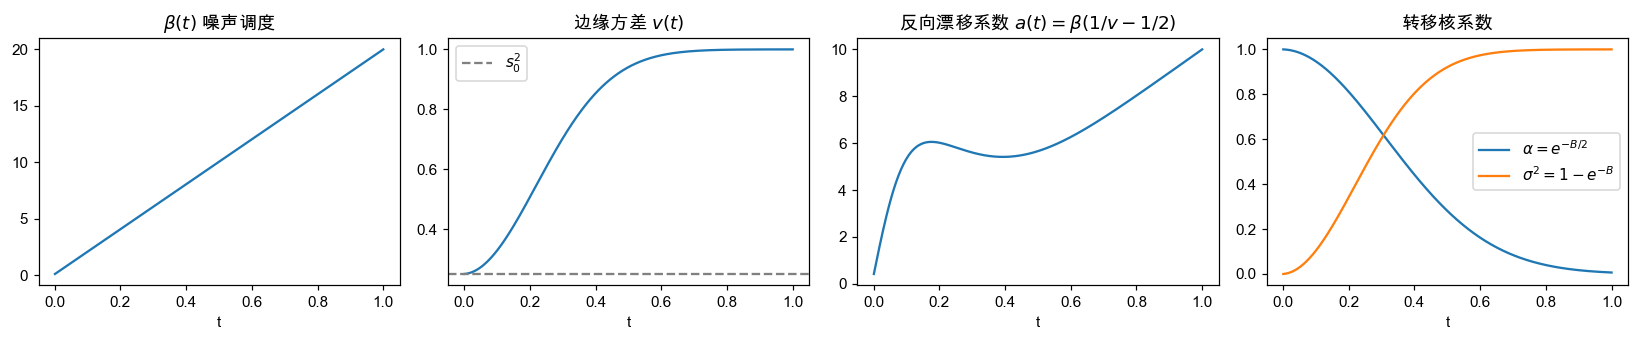

In [3]:
# 图1：噪声调度与边缘量
ts = np.linspace(EPS, 1.0, 400)
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
ax[0].plot(ts, dna.beta(ts));                      ax[0].set_title(r'$\beta(t)$ 噪声调度')
ax[1].plot(ts, dna.marginal_var(ts));              ax[1].axhline(S0**2, ls='--', c='gray', label=r'$s_0^2$')
ax[1].set_title(r'边缘方差 $v(t)$'); ax[1].legend()
ax[2].plot(ts, dna.reverse_drift_coeff(ts));       ax[2].set_title(r'反向漂移系数 $a(t)=\beta(1/v-1/2)$')
ax[3].plot(ts, dna.alpha(ts), label=r'$\alpha=e^{-B/2}$')
ax[3].plot(ts, dna.sigma2(ts), label=r'$\sigma^2=1-e^{-B}$'); ax[3].legend(); ax[3].set_title('转移核系数')
for a in ax: a.set_xlabel('t')
plt.tight_layout(); plt.savefig('figures/fig01_schedule.png', bbox_inches='tight'); plt.show()

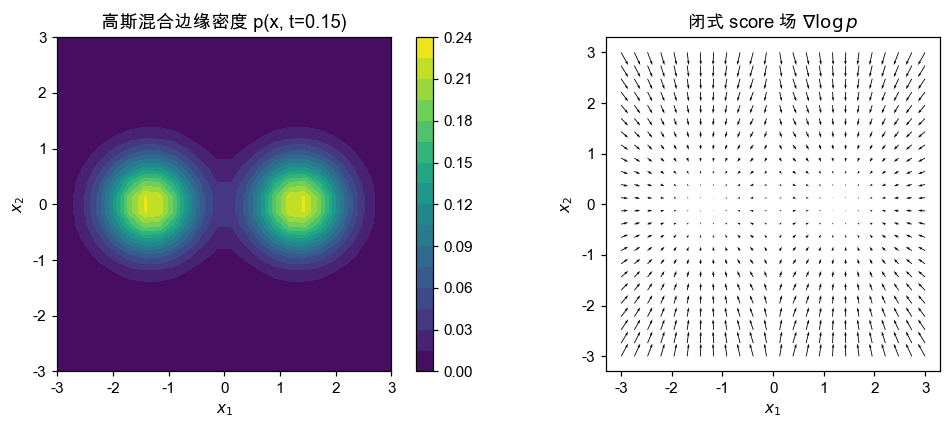

In [4]:
# 图2：高斯混合的闭式 score 场（引入非线性的解析参照）
means = np.array([[-1.5, 0.0], [1.5, 0.0]]); weights = np.array([0.5, 0.5]); s0g = 0.4
t_show = 0.15
g = np.linspace(-3, 3, 24); X, Y = np.meshgrid(g, g)
pts = np.stack([X.ravel(), Y.ravel()], 1)
Sv = dna.exact_score_gmm(pts, t_show, means, weights, s0g)
logp = dna.gmm_log_marginal(pts, t_show, means, weights, s0g).reshape(X.shape)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
c = ax[0].contourf(X, Y, np.exp(logp), levels=20, cmap='viridis'); plt.colorbar(c, ax=ax[0])
ax[0].set_title(f'高斯混合边缘密度 p(x, t={t_show})')
ax[1].quiver(X, Y, Sv[:, 0].reshape(X.shape), Sv[:, 1].reshape(X.shape))
ax[1].set_title(r'闭式 score 场 $\nabla\log p$')
for a in ax: a.set_aspect('equal'); a.set_xlabel('$x_1$'); a.set_ylabel('$x_2$')
plt.tight_layout(); plt.savefig('figures/fig02_gmm_score.png', bbox_inches='tight'); plt.show()

## Part II　采样即数值积分：误差与收敛

### §3 反向 EM 的矩封闭递推
把 §1 的 Anderson 反向 SDE 在一维上代入线性分数 $s^*=-x/v$，反向漂移为 $a(t)x$。离散时取反向时间 $\tau=1-t$、正步长 $h=t_n-t_{n+1}=-\mathrm{d}t>0$（$t$ 由 $1$ 减到 $\varepsilon$）。反向过程在前向时间写法下是 $\mathrm{d}Y=a(t)Y\,\mathrm{d}t+\sqrt{\beta}\,\mathrm{d}\bar W$（其中 $\mathrm{d}t<0$），换到反向时间即 $\mathrm{d}Y=-a(1-\tau)Y\,\mathrm{d}\tau+\sqrt{\beta}\,\mathrm{d}\tilde W$，与 §2 的约定表一致。对它做 Euler–Maruyama（步长 $h$）：

$$x_{n+1}=(1-a(t_n)h)\,x_n+\sqrt{\beta(t_n)h}\,\zeta_n,\quad\zeta_n\sim\mathcal N(0,1).$$

因为过程是线性高斯的，均值恒为 0，方差满足一个确定性递推（不含蒙特卡洛噪声）：

$$\boxed{\,V_{n+1}=(1-a(t_n)h)^2\,V_n+\beta(t_n)h\,}.$$

它的连续极限（反向时间 $\tau$）为 $\;\mathrm{d}V/\mathrm{d}\tau=-2a(1-\tau)V+\beta(1-\tau)$。这里的因子 $2$ 来自 Itô 公式 $\mathrm{d}\,\mathbb E[Y^2]=(2a\,\mathbb E[Y^2]+\beta)\mathrm{d}\tau$；若把它漏掉，求得的末端方差会是 $0.76$ 而非正确的 $0.25$（已数值核对）。

### §4 后向误差分析：EM 实际在求解哪条方程
把上面的递推按 $h$ 展开成 $V_{n+1}=V_n+hF+h^2G$，其中

$$F(\tau,V)=-2a\,V+\beta,\qquad G(\tau,V)=a^2V\ \ (\text{来自}(1-ah)^2\text{中的}a^2h^2V\text{项}).$$

设 EM 实际精确求解的修正方程为 $V'=F+hH+O(h^2)$，对一步做 Taylor 展开并匹配（沿精确解有 $F_\tau+F_V F=V''$），得

$$\boxed{\,H=G-\tfrac12\big(F_\tau+F_V F\big)=a^2V-\tfrac12 V''\,}.$$

于是生成分布方差的领头阶偏差为 $V_N-v(\varepsilon)=c\,h+O(h^2)$，系数

$$c=\int_0^{T}\Phi(T,s)\big[\,[a(1-s)]^2V(s)-\tfrac12V''(s)\,\big]\mathrm{d}s,\qquad \Phi(T,s)=\exp\!\Big(\!\int_s^{T}-2a(1-r)\,\mathrm{d}r\Big),$$

其中 $T=1-\varepsilon$。系数里 $a^2V$ 一项来自噪声注入与漂移在离散后的耦合，$-\tfrac12V''$ 一项来自漂移的前向 Euler 截断。后者的存在说明，仅把线性漂移做指数化处理并不能完全消去偏差（噪声项仍贡献 $O(h)$）。

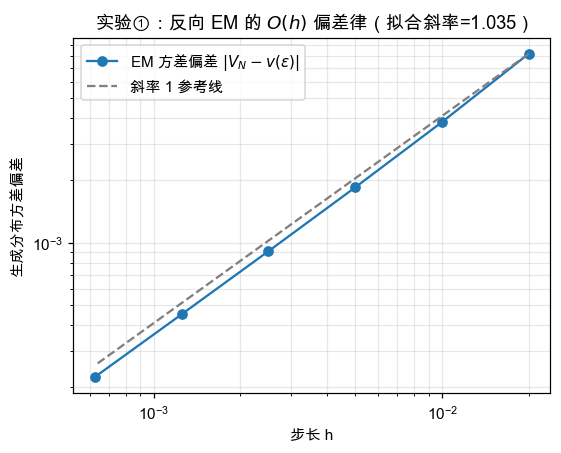

解析真值 v(eps) = 0.250082 ; reverse_variance_exact = 0.250082
拟合斜率 = 1.0345  (理论弱阶 = 1)


In [5]:
# 实验①：O(h) 偏差律（确定性递推，免训练、微秒级）
Ns = np.array([50, 100, 200, 400, 800, 1600])
target = dna.reverse_variance_exact(EPS, V_start=dna.marginal_var(1.0))   # 解析真值（含因子2）
errs = np.array([abs(dna.em_variance_recursion(N, V_start=dna.marginal_var(1.0)) - target) for N in Ns])
hs = (1.0 - EPS) / Ns
slope = np.polyfit(np.log(hs), np.log(errs), 1)[0]

plt.figure(figsize=(5.6, 4.2))
plt.loglog(hs, errs, 'o-', label=r'EM 方差偏差 $|V_N-v(\varepsilon)|$')
plt.loglog(hs, errs[0] * (hs / hs[0]), '--', c='gray', label='斜率 1 参考线')
plt.xlabel('步长 h'); plt.ylabel('生成分布方差偏差')
plt.title('实验①：反向 EM 的 $O(h)$ 偏差律（拟合斜率=%.3f）' % slope)
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.savefig('figures/fig03_bias_law.png', bbox_inches='tight'); plt.show()

print('解析真值 v(eps) = %.6f ; reverse_variance_exact = %.6f' % (dna.marginal_var(EPS), target))
print('拟合斜率 = %.4f  (理论弱阶 = 1)' % slope)
assert 0.85 < slope < 1.15, slope

**实验①分析.** 双对数坐标下，偏差随步长 $h$ 沿斜率约 $1$ 的直线下降，说明反向 EM 在生成分布方差上的弱收敛阶为 $1$；同时解析值 $v(\varepsilon)=0.2501$ 与高精度反向方差 ODE 的末端一致。整条曲线由确定性递推算出，不含蒙特卡洛噪声，也不需要训练，可作为后续各项误差分析的参照。需要说明的是，在线性高斯设定下弱阶为 $1$ 本身是矩递推相容性的直接结果，几乎是必然的；真正包含信息的是 §4 中修正方程的系数，以及 §5 对加性、乘性两种噪声强阶的对照。

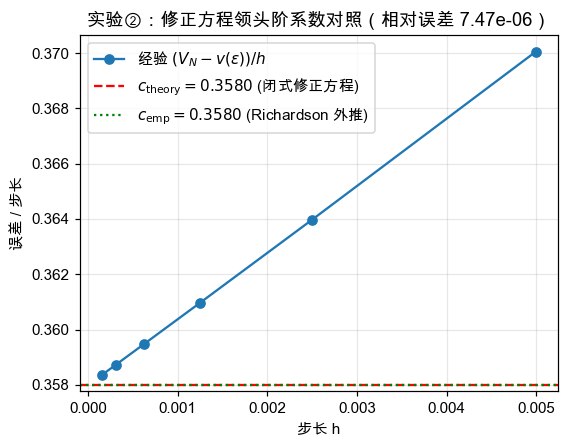

c_theory=0.357984  c_emp=0.357981  相对误差=7.47e-06


In [6]:
# 实验②：修正方程系数 c_theory vs Richardson 经验 c_emp
c_th = dna.bias_coeff_theory()
c_emp = dna.bias_coeff_empirical()
rel = abs(c_th - c_emp) / abs(c_emp)

Ns2 = np.array([200, 400, 800, 1600, 3200, 6400]); hs2 = (1.0 - EPS) / Ns2
ratios = np.array([(dna.em_variance_recursion(N, V_start=dna.marginal_var(1.0)) - target) / h
                   for N, h in zip(Ns2, hs2)])
plt.figure(figsize=(5.6, 4.2))
plt.plot(hs2, ratios, 'o-', label=r'经验 $(V_N-v(\varepsilon))/h$')
plt.axhline(c_th, ls='--', c='r', label=r'$c_{\rm theory}=%.4f$ (闭式修正方程)' % c_th)
plt.axhline(c_emp, ls=':', c='g', label=r'$c_{\rm emp}=%.4f$ (Richardson 外推)' % c_emp)
plt.xlabel('步长 h'); plt.ylabel('误差 / 步长'); plt.legend()
plt.title('实验②：修正方程领头阶系数对照（相对误差 %.2e）' % rel)
plt.grid(True, alpha=0.3)
plt.savefig('figures/fig04_coeff.png', bbox_inches='tight'); plt.show()

print('c_theory=%.6f  c_emp=%.6f  相对误差=%.2e' % (c_th, c_emp, rel))
assert rel < 1e-3, rel          # 理论闭式与 Richardson 经验值高度吻合（实测 ~7.5e-6）

**实验②分析.** 手推的系数 $c_{\rm theory}\approx0.35798$ 与完全独立的 Richardson 外推值 $c_{\rm emp}\approx0.35798$ 吻合到相对误差约 $7.5\times10^{-6}$。这说明 §4 的推导是对的，包括 $a^2V$ 这一离散耦合项、含因子 $2$ 的传播子以及解析二阶导 $V''$；也就回答了"EM 实际在求解哪条被修正的方程"。这一分析与 Lect5 处理 SGD 时用的修正方程是同一套方法。

### §5 收敛阶：加性噪声下 EM 的强阶为 1
通常说 Euler–Maruyama 的强阶为 $1/2$、弱阶为 $1$，但 $1/2$ 这一结论只对乘性噪声（扩散系数依赖状态）成立。本文反向 SDE 的扩散项 $\sqrt{\beta(t)}$ 与状态无关，属于加性噪声，此时 EM 的强阶提升为 $1$（弱阶同样为 $1$）。下面用共享布朗路径来验证：以最细网格的 EM 解为参照，粗网格用对应细增量之和驱动，测强误差 $\mathbb E|Y^{\rm coarse}-Y^{\rm fine}|$。作为对照，再取一个乘性噪声的例子（几何布朗运动），它的强阶应为 $1/2$。

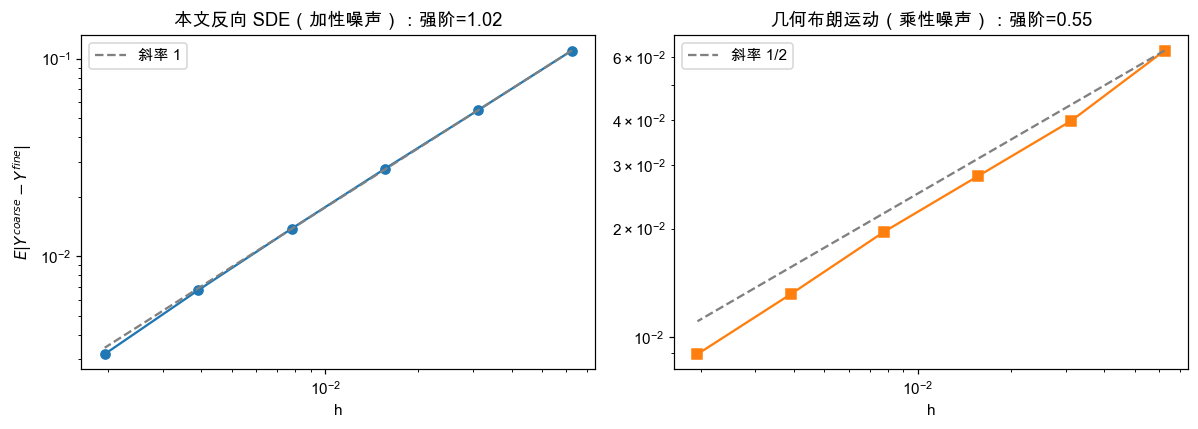

加性噪声强阶≈1.018（理论1）；乘性噪声(GBM)强阶≈0.552（理论1/2）


In [7]:
# 实验③：强收敛阶 —— 加性噪声(本问题) 强阶=1，对比乘性噪声(GBM) 强阶=1/2
rng = np.random.default_rng(7)
x0v = 0.7; Nf = 4096; n_paths = 4000
hf = (1.0 - EPS) / Nf
dWf = rng.standard_normal((n_paths, Nf)) * np.sqrt(hf)   # 最细布朗增量

def em_paths_additive(N, dW_steps):
    ts_ = np.linspace(1.0, EPS, N + 1); x = np.full(dW_steps.shape[0], x0v)
    for i in range(N):
        t = ts_[i]; h = ts_[i] - ts_[i + 1]; a = dna.reverse_drift_coeff(t, S0)
        x = (1 - a * h) * x + np.sqrt(dna.beta(t)) * dW_steps[:, i]
    return x

Xref = em_paths_additive(Nf, dWf)
levels = np.array([16, 32, 64, 128, 256, 512])
strong = []
for N in levels:
    k = Nf // N
    dWc = dWf.reshape(n_paths, N, k).sum(axis=2)         # 共享路径：粗增量=细增量之和
    strong.append(np.mean(np.abs(em_paths_additive(N, dWc) - Xref)))
strong = np.array(strong); hs3 = (1.0 - EPS) / levels
slope_add = np.polyfit(np.log(hs3), np.log(strong), 1)[0]

# 乘性噪声对照：几何布朗运动 GBM dY=-Y dt + Y dW，精确解 Y_T=Y0 exp((-1-1/2)T + W_T)
T = 1.0; Y0 = 1.0; mu, sig = -1.0, 1.0
dWg = rng.standard_normal((n_paths, Nf)) * np.sqrt(T / Nf)
WT = dWg.sum(1); Yexact = Y0 * np.exp((mu - 0.5 * sig**2) * T + sig * WT)
strong_g = []
for N in levels:
    k = Nf // N; hg = T / N; dWc = dWg.reshape(n_paths, N, k).sum(2)
    y = np.full(n_paths, Y0)
    for i in range(N):
        y = y + mu * y * hg + sig * y * dWc[:, i]
    strong_g.append(np.mean(np.abs(y - Yexact)))
strong_g = np.array(strong_g); hg3 = T / levels
slope_mul = np.polyfit(np.log(hg3), np.log(strong_g), 1)[0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].loglog(hs3, strong, 'o-'); ax[0].loglog(hs3, strong[0]*(hs3/hs3[0]), '--', c='gray', label='斜率 1')
ax[0].set_title('本文反向 SDE（加性噪声）：强阶=%.2f' % slope_add); ax[0].set_xlabel('h'); ax[0].set_ylabel(r'$E|Y^{coarse}-Y^{fine}|$'); ax[0].legend()
ax[1].loglog(hg3, strong_g, 's-', c='C1'); ax[1].loglog(hg3, strong_g[0]*np.sqrt(hg3/hg3[0]), '--', c='gray', label='斜率 1/2')
ax[1].set_title('几何布朗运动（乘性噪声）：强阶=%.2f' % slope_mul); ax[1].set_xlabel('h'); ax[1].legend()
plt.tight_layout(); plt.savefig('figures/fig05_strong_order.png', bbox_inches='tight'); plt.show()
print('加性噪声强阶≈%.3f（理论1）；乘性噪声(GBM)强阶≈%.3f（理论1/2）' % (slope_add, slope_mul))
assert 0.8 < slope_add < 1.2, slope_add
assert 0.3 < slope_mul < 0.7, slope_mul

**实验③分析.** 左图中本文反向 SDE（加性噪声）的 EM 强阶约为 $1$；右图几何布朗运动（乘性噪声）的强阶约为 $1/2$，与通常结论一致。可见扩散反向采样属于加性噪声，其 EM 路径精度实际是一阶的，笼统地套用"EM 强阶为 $1/2$"在这里并不合适。

## Part III　稳定性与刚性

### §6 显式 Euler 的绝对稳定域
反向漂移的 Jacobian 是标量 $a(t)>0$，可用 $L(t)=a(t)$ 衡量其稳定性时间尺度。EM 方差递推的放大因子是 $(1-a(t)h)^2$，要求每步不放大（绝对稳定），需

$$|1-a(t)h|\le1\ \Longleftrightarrow\ 0\le h\le \frac{2}{a(t)}.$$

$a(t)=\beta(t)(1/v(t)-\tfrac12)$ 在 $t\to1$ 处最大，主要是因为 $\beta(t)$ 增至 $20$（此时 $v\to1$，$1/v-\tfrac12$ 一项反而降到最小值 $\tfrac12$，但 $\beta$ 的增长占主导），$a(1)\approx10.0$，因此最严格的稳定步长约 $h\le0.2$，对应临界步数 $N^*\approx(1-\varepsilon)\,a_{\max}/2\approx5$。需要注意的是，概率流 ODE 并不存在这一约束（当 $v\to1$ 时其漂移系数 $\tfrac12\beta(1/v-1)\to0$），这也是确定性 ODE 采样往往能用更少步数的原因。

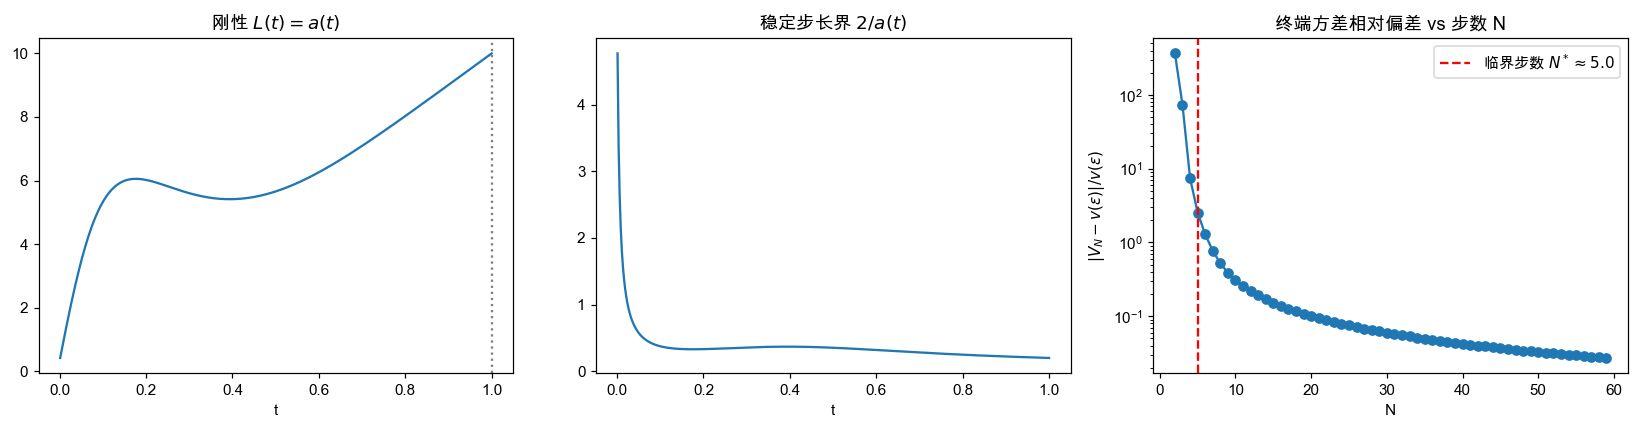

最刚处 t≈1.000, a_max≈10.00, 临界步数 N*≈5.0


In [8]:
# 实验④：刚性诊断 + 稳定步长界 + 失稳演示
tt = np.linspace(EPS, 1.0, 400)
L = dna.stiffness(tt); cdt = dna.critical_dt(tt)
amax = dna.stiffness(np.linspace(EPS, 1, 2000)).max()
Nstar = (1.0 - EPS) * amax / 2.0
Ns_s = np.arange(2, 60)
v_eps = dna.marginal_var(EPS)
reldev = np.array([abs(dna.em_variance_recursion(int(N), V_start=dna.marginal_var(1.0)) - v_eps) / v_eps
                   for N in Ns_s])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(tt, L); ax[0].axvline(1.0, ls=':', c='gray'); ax[0].set_title(r'刚性 $L(t)=a(t)$'); ax[0].set_xlabel('t')
ax[1].plot(tt, cdt); ax[1].set_title(r'稳定步长界 $2/a(t)$'); ax[1].set_xlabel('t')
ax[2].semilogy(Ns_s, reldev + 1e-16, 'o-'); ax[2].axvline(Nstar, ls='--', c='r', label=r'临界步数 $N^*\approx%.1f$' % Nstar)
ax[2].set_title('终端方差相对偏差 vs 步数 N'); ax[2].set_xlabel('N'); ax[2].set_ylabel(r'$|V_N-v(\varepsilon)|/v(\varepsilon)$'); ax[2].legend()
plt.tight_layout(); plt.savefig('figures/fig06_stiffness.png', bbox_inches='tight'); plt.show()
print('最刚处 t≈%.3f, a_max≈%.2f, 临界步数 N*≈%.1f' % (tt[np.argmax(L)], amax, Nstar))
assert dna.em_blows_up(3) and not dna.em_blows_up(50)

**实验④分析.** $L(t)=a(t)$ 在 $t\approx1$ 处达到峰值约 $10$，对应稳定步长上界 $2/a\approx0.2$。从右图可以看出：当 $N\le3$（即 $h>2/a$）时 $|1-ah|>1$，迭代被放大、方差发散（`em_blows_up` 为真）；$N=4,5$ 接近临界，偏差达数倍但尚未发散；$N\gtrsim6$ 之后单调收敛。这就把"步数不能太少"这一经验，化成了一个可计算的稳定步长判据。需要说明的是，这里说的"稳定性约束"指显式格式的步长上界 $h\le2/a$，本问题 $a\!\cdot\!T\approx10$ 量级温和，并不是传统意义上的多尺度刚性；它来自 $\beta(t)$ 增大，而非 $t\to0$（$s_0>0$ 时 $1/v$ 有界，只有理想流形 $s_0\to0$ 才会在 $t\to0$ 处出现奇异）。

## Part IV　改进的采样器

### §7 半隐式/指数处理线性漂移与 Richardson 外推
反向 SDE 的漂移是线性的，可以对其做常系数指数（半隐式）步：$x\leftarrow e^{-a h}x+(\text{噪声项的精确积分})$，相应的方差递推为 $V\leftarrow e^{-2ah}V+\beta\frac{1-e^{-2ah}}{2a}$。这一步在每个区间上把常系数部分处理得精确，但由于 $a,\beta$ 随时间变化，整体仍是一阶方法，只是误差常数更小，并不能达到机器精度。另一种不需额外推导就能提阶的办法是 Richardson 外推：对一阶方法，用 $2V_{2N}-V_N$ 消去 $O(h)$ 项即得 $O(h^2)$。

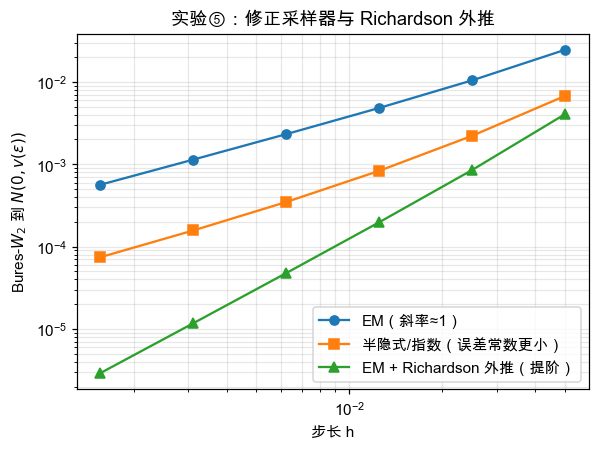

EM 斜率=1.08  半隐式最粗步误差=6.78e-03 vs EM=2.46e-02  Richardson 斜率=2.08


In [9]:
# 实验⑤：半隐式/指数修正 + Richardson 外推（1-D Bures-W2 = |√V - √v(ε)|）
Ns5 = np.array([20, 40, 80, 160, 320, 640]); hs5 = (1.0 - EPS) / Ns5
v_eps = dna.marginal_var(EPS)
w2 = lambda V: abs(np.sqrt(max(V, 0.0)) - np.sqrt(v_eps))
em_w = np.array([w2(dna.em_variance_recursion(N, V_start=dna.marginal_var(1.0))) for N in Ns5])
si_w = np.array([w2(dna.semiimplicit_variance_recursion(N, V_start=dna.marginal_var(1.0))) for N in Ns5])
rich_w = np.array([w2(2 * dna.em_variance_recursion(2 * N, V_start=dna.marginal_var(1.0))
                      - dna.em_variance_recursion(N, V_start=dna.marginal_var(1.0))) for N in Ns5])

plt.figure(figsize=(6, 4.2))
plt.loglog(hs5, em_w, 'o-', label='EM（斜率≈1）')
plt.loglog(hs5, si_w, 's-', label='半隐式/指数（误差常数更小）')
plt.loglog(hs5, rich_w, '^-', label='EM + Richardson 外推（提阶）')
plt.xlabel('步长 h'); plt.ylabel(r'Bures-$W_2$ 到 $N(0,v(\varepsilon))$')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.title('实验⑤：修正采样器与 Richardson 外推')
plt.savefig('figures/fig07_corrected.png', bbox_inches='tight'); plt.show()
s_em = np.polyfit(np.log(hs5), np.log(em_w), 1)[0]
s_rich = np.polyfit(np.log(hs5), np.log(rich_w), 1)[0]
print('EM 斜率=%.2f  半隐式最粗步误差=%.2e vs EM=%.2e  Richardson 斜率=%.2f' % (s_em, si_w[0], em_w[0], s_rich))
assert si_w[0] < em_w[0]            # 指数法误差常数更小
assert s_rich > s_em + 0.4          # Richardson 提阶

**实验⑤分析.** 半隐式/指数法把 EM 的误差常数压低（两者同为一阶），Richardson 外推则把收敛阶从约 $1$ 提到约 $2$。这与 §7 的判断一致：单独把线性漂移指数化不足以消去偏差（噪声项仍贡献 $O(h)$），而外推能系统地提阶。

### §8 概率流 ODE 与指数积分器
与反向 SDE 共享同一族边缘的概率流 ODE 为

$$\frac{\mathrm{d}x}{\mathrm{d}t}=f_{\rm pf}(t,x)=-\tfrac12\beta x-\tfrac12\beta\,\nabla\log p=\tfrac12\beta(t)\big(1/v(t)-1\big)x,$$

它是 DPM-Solver、DEIS 等少步采样器的数学基础。注意 $f_{\rm pf}$ 是前向时间（$t$ 增）的漂移，反向采样时每步为 $x_{n+1}=x_n-h\,f_{\rm pf}(t_n,x_n)$（$t$ 由 $1$ 减到 $\varepsilon$），符号相反。在高斯设定下，它有闭式解

$$\boxed{\,x(t)=\sqrt{v(t)/v(1)}\;x(1)\,},$$

可以作为高精度参照。下面验证 Euler 与 Heun 相对该闭式解的收敛阶（这条 ODE 不受稳定域约束，少步即可），并在 Swiss-Roll 上用训练得到的网络 score 画出 NFE 与样本质量的关系。

训练 Swiss-Roll score 网络 (device=cpu) ...


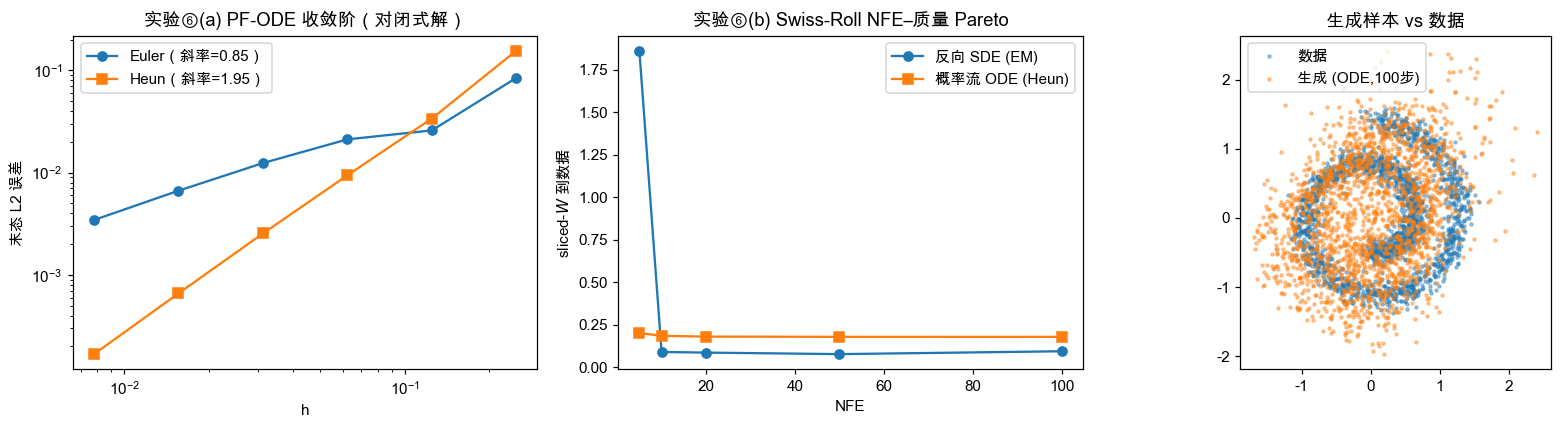

PF-ODE: Euler 斜率=0.85, Heun 斜率=1.95


In [10]:
# 实验⑥(a)：概率流 ODE 对闭式精确解的收敛阶（1-D）
refx = dna.pf_ode_exact(2.0)
Ns6 = np.array([4, 8, 16, 32, 64, 128]); hs6 = (1.0 - EPS) / Ns6
e_eu = np.array([abs(dna.pf_ode_sample(N, 'euler', 2.0) - refx) for N in Ns6])
e_he = np.array([abs(dna.pf_ode_sample(N, 'heun', 2.0) - refx) for N in Ns6])
s_eu = np.polyfit(np.log(hs6), np.log(e_eu), 1)[0]
s_he = np.polyfit(np.log(hs6), np.log(e_he), 1)[0]

# 实验⑥(b)：Swiss-Roll 上用训练网络 score 的 NFE-质量 Pareto
data2d = dna.make_swiss_roll_2d(2000, seed=0)
print('训练 Swiss-Roll score 网络 (device=%s) ...' % DEVICE)
net2d = dna.train_score_net_data(data2d, n_iters=6000, device=DEVICE, seed=0)
net_score = lambda x, t: dna.eval_score_net(net2d, x, t, device=DEVICE)
nfes = [5, 10, 20, 50, 100]
qual = {'em': [], 'pf_heun': []}
for m in qual:
    for N in nfes:
        Xg = dna.reverse_sample(net_score, N, m, n_samples=2000, dim=2, eps=EPS, seed=1)
        qual[m].append(dna.sliced_wasserstein(Xg, data2d))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].loglog(hs6, e_eu, 'o-', label='Euler（斜率=%.2f）' % s_eu)
ax[0].loglog(hs6, e_he, 's-', label='Heun（斜率=%.2f）' % s_he)
ax[0].set_title('实验⑥(a) PF-ODE 收敛阶（对闭式解）'); ax[0].set_xlabel('h'); ax[0].set_ylabel('末态 L2 误差'); ax[0].legend()
ax[1].plot(nfes, qual['em'], 'o-', label='反向 SDE (EM)')
ax[1].plot(nfes, qual['pf_heun'], 's-', label='概率流 ODE (Heun)')
ax[1].set_title('实验⑥(b) Swiss-Roll NFE–质量 Pareto'); ax[1].set_xlabel('NFE'); ax[1].set_ylabel('sliced-$W$ 到数据'); ax[1].legend()
Xbest = dna.reverse_sample(net_score, 100, 'pf_heun', n_samples=2000, dim=2, eps=EPS, seed=1)
ax[2].scatter(data2d[:, 0], data2d[:, 1], s=4, alpha=.4, label='数据')
ax[2].scatter(Xbest[:, 0], Xbest[:, 1], s=4, alpha=.4, label='生成 (ODE,100步)')
ax[2].set_title('生成样本 vs 数据'); ax[2].legend(); ax[2].set_aspect('equal')
plt.tight_layout(); plt.savefig('figures/fig08_exp_integrator.png', bbox_inches='tight'); plt.show()
print('PF-ODE: Euler 斜率=%.2f, Heun 斜率=%.2f' % (s_eu, s_he))
assert s_he > s_eu + 0.5            # Heun 阶高于 Euler（仅 ODE 成立）

**实验⑥分析.** (a) 概率流 ODE 不受稳定域约束，Euler 与 Heun 分别以约 $1$、约 $2$ 阶收敛到闭式解 $x\propto\sqrt v$，少步就能达到较高精度，这正是 DPM-Solver 一类少步采样有效的原因。(b) Swiss-Roll 上比较随机 EM 与确定性 ODE（Heun）的 sliced-Wasserstein 随 NFE 的变化：当 NFE$\ge$10 时两者质量接近；在最少步（NFE=5）处结果对随机性和步长都很敏感，因为此时 EM 恰好落在稳定性临界 $N^*\approx5$ 附近，单步可能越出稳定域。还需说明一点：单纯把系数冻结做指数步，在含 score 项时未必优于 Euler，其优势仅体现在线性漂移部分；少步采样真正的收益来自概率流 ODE 不受稳定域约束以及高阶格式，而不是简单的指数化。

### §9 随机与确定性采样器的偏差–方差（探索性）

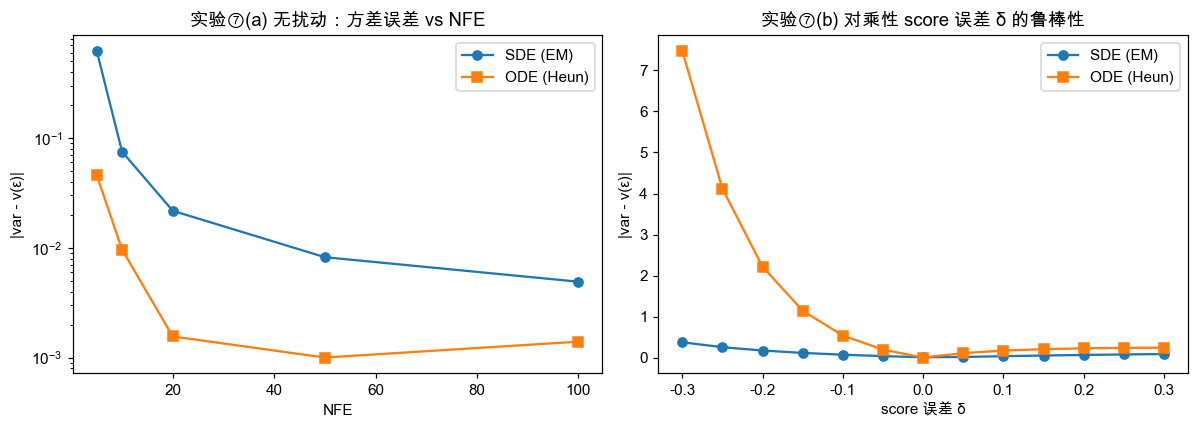

探索性实验：报告曲线形态，不作硬断言。


In [11]:
# 实验⑦：SDE(EM) vs ODE(Heun) 的矩误差与对 score 误差的鲁棒性（探索性，不做硬断言）
gscore = lambda x, t: dna.exact_score_gaussian(x, t, S0)
Ns7 = [5, 10, 20, 50, 100]
em_e = [abs(dna.reverse_sample(gscore, N, 'em', n_samples=40000, dim=1, eps=EPS, seed=2).var() - v_eps) for N in Ns7]
od_e = [abs(dna.reverse_sample(gscore, N, 'pf_heun', n_samples=40000, dim=1, eps=EPS, seed=3).var() - v_eps) for N in Ns7]

deltas = np.linspace(-0.3, 0.3, 13)   # 乘性 score 误差 s_pert=(1+δ)s
rob_em, rob_od = [], []
for d in deltas:
    sp = lambda x, t, d=d: (1.0 + d) * dna.exact_score_gaussian(x, t, S0)
    rob_em.append(abs(dna.reverse_sample(sp, 50, 'em', n_samples=40000, dim=1, eps=EPS, seed=4).var() - v_eps))
    rob_od.append(abs(dna.reverse_sample(sp, 50, 'pf_heun', n_samples=40000, dim=1, eps=EPS, seed=5).var() - v_eps))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Ns7, em_e, 'o-', label='SDE (EM)'); ax[0].plot(Ns7, od_e, 's-', label='ODE (Heun)')
ax[0].set_title('实验⑦(a) 无扰动：方差误差 vs NFE'); ax[0].set_xlabel('NFE'); ax[0].set_ylabel('|var - v(ε)|'); ax[0].legend(); ax[0].set_yscale('log')
ax[1].plot(deltas, rob_em, 'o-', label='SDE (EM)'); ax[1].plot(deltas, rob_od, 's-', label='ODE (Heun)')
ax[1].set_title('实验⑦(b) 对乘性 score 误差 δ 的鲁棒性'); ax[1].set_xlabel('score 误差 δ'); ax[1].set_ylabel('|var - v(ε)|'); ax[1].legend()
plt.tight_layout(); plt.savefig('figures/fig09_bias_variance.png', bbox_inches='tight'); plt.show()
print('探索性实验：报告曲线形态，不作硬断言。')
assert np.all(np.isfinite(em_e)) and np.all(np.isfinite(rob_od))

**实验⑦分析（探索性）.** 无扰动时，确定性 ODE 与随机 SDE 的方差误差随 NFE 同步下降。在乘性 score 误差 $\delta$ 下，本次实验里负向扰动（$\delta<0$）时 ODE（Heun）的误差增长明显快于 EM，正向扰动时两者相近，可见"随机性能自我校正 score 误差"这一说法依赖于扰动的方向，并不普遍成立。它本身就取决于扰动模型与所用指标，因此这里只作为探索性观察列出，不下定论。

## Part V　误差预算与 score 质量诊断

这一部分需要一个训练得到的网络 score。我们在一维高斯数据上用 DSM 训练一个小 MLP，并保留解析值 $s^*=-x/v$ 作参照，供实验⑧⑨⑩共用。

In [12]:
# 训练 1-D 网络 score（供实验⑧⑨⑩共用）
print('训练 1-D 高斯 score 网络 (device=%s) ...' % DEVICE)
net1d = dna.train_score_net_gaussian(s0=S0, n_iters=5000, device=DEVICE, dim=1, seed=0)
net1d_score = lambda x, t: dna.eval_score_net(net1d, x, t, device=DEVICE)
# 抽检：t=0.3 时网络 score vs 解析
xs = np.linspace(-1, 1, 11).reshape(-1, 1)
mse = np.mean((dna.eval_score_net(net1d, xs, 0.3, DEVICE) - dna.exact_score_gaussian(xs, 0.3, S0))**2)
print('网络 score 在 t=0.3 的 MSE = %.4f （越小越准）' % mse)

训练 1-D 高斯 score 网络 (device=cpu) ...


网络 score 在 t=0.3 的 MSE = 0.0007 （越小越准）


### §10 总采样误差的三个来源
反向采样的总误差可归到三个来源：先验失配 $e_{\rm prior}$（起点用 $\mathcal N(0,I)$，而真边缘是 $\mathcal N(0,v(1))$）、时间离散 $e_{\rm disc}$（有限步长的格式误差）、分数估计 $e_{\rm score}$（网络 score 与真值之差）。在一维高斯上，可以把这三项分别独立地测出来（用 Bures-$W_2=|\sqrt{\cdot}-\sqrt{v(\varepsilon)}|$）：

- $e_{\rm prior}=|\sqrt{1}-\sqrt{v(1)}|$，是起点先验与真边缘之差，与步数无关；
- $e_{\rm disc}=|\sqrt{V_B}-\sqrt{v(\varepsilon)}|$，其中 $V_B$ 为用精确 score、从真边缘 $v(1)$ 出发、粗步 EM 得到的终端方差，只含离散误差；
- $e_{\rm score}=|\sqrt{V_C}-\sqrt{V_B}|$，其中 $V_C$ 为用网络 score、同样粗步得到的终端方差，相对前者的偏移即分数误差的贡献。

需要说明的是，一般情形下采样误差并不严格线性可加，这里给出的是量级上的归因（三项之和与实测总误差量级相当），而非严格上界；若要严格上界，可用三角不等式 $W_2\le e_{\rm prior}+e_{\rm disc}+e_{\rm score}$ 分别估计各项。

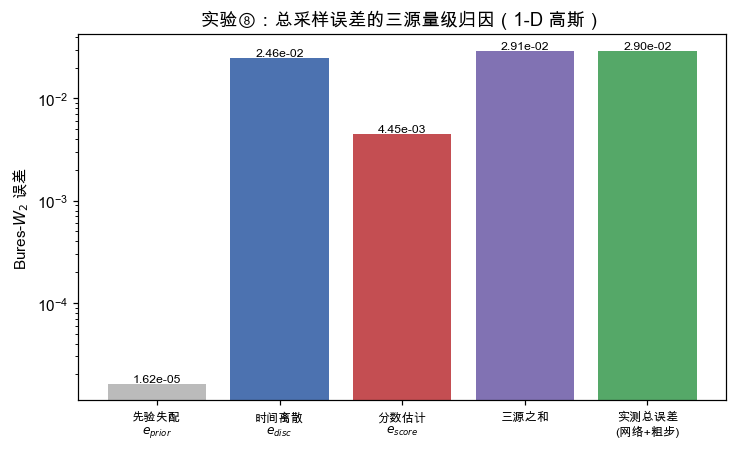

e_prior=1.619e-05  e_disc=2.459e-02  e_score=4.451e-03  三源和=2.906e-02  实测总=2.904e-02


In [13]:
# 实验⑧：误差三分解（1-D 高斯，三源各自独立测量；近似可加，非严格上界）
v_eps = dna.marginal_var(EPS); v1 = dna.marginal_var(1.0)
w2 = lambda V: abs(np.sqrt(max(V, 0.0)) - np.sqrt(v_eps))
N_coarse = 20
V_B = dna.em_variance_recursion(N_coarse, V_start=v1)                                  # 精确score+真起点+粗步
V_C = dna.reverse_sample(net1d_score, N_coarse, 'em', n_samples=200000, dim=1, eps=EPS, seed=6).var()
e_prior = abs(np.sqrt(1.0) - np.sqrt(v1))                                              # 先验失配（与步数无关）
e_disc  = w2(V_B)                                                                      # 纯离散
e_score = abs(np.sqrt(max(V_C, 0.0)) - np.sqrt(V_B))                                   # 分数估计贡献
e_total = w2(V_C)                                                                      # 网络+粗步 实测总误差

fig, ax = plt.subplots(figsize=(6.8, 4.2))
labels = ['先验失配\n$e_{prior}$', '时间离散\n$e_{disc}$', '分数估计\n$e_{score}$', '三源之和', '实测总误差\n(网络+粗步)']
vals = [e_prior, e_disc, e_score, e_prior + e_disc + e_score, e_total]
colors = ['#bbb', '#4C72B0', '#C44E52', '#8172B3', '#55A868']
ax.bar(range(5), vals, color=colors)
for i, v in enumerate(vals):
    ax.text(i, v, '%.2e' % v, ha='center', va='bottom', fontsize=8)
ax.set_xticks(range(5)); ax.set_xticklabels(labels, fontsize=8)
ax.set_yscale('log'); ax.set_ylabel(r'Bures-$W_2$ 误差'); ax.set_title('实验⑧：总采样误差的三源量级归因（1-D 高斯）')
plt.tight_layout(); plt.savefig('figures/fig10_error_budget.png', bbox_inches='tight'); plt.show()
print('e_prior=%.3e  e_disc=%.3e  e_score=%.3e  三源和=%.3e  实测总=%.3e'
      % (e_prior, e_disc, e_score, e_prior + e_disc + e_score, e_total))
assert e_disc > 0 and e_score > 0          # 离散与分数误差均可见
assert e_prior < e_disc                    # 本调度下先验失配可忽略

**实验⑧分析.** 三项误差被分别测出且彼此分离：本调度下先验失配可忽略（约 $10^{-5}$，因为 $v(1)\approx1$），占主导的是粗步的时间离散误差与网络的分数估计误差，三项之和与实测总误差量级相当。这样一个各有解析参照、可分项度量的误差预算，把"扩散为什么生成不准"从经验判断变成了可量化的归因。

### §11 用 Fokker–Planck 残差诊断 score 质量
对 VP 过程，真实 $\log p$ 满足如下 log-FPE 恒等式

$$\partial_t\log p-\tfrac12\beta\big[d+x\!\cdot\!s+\|s\|^2+\nabla\!\cdot\!s\big]=0,\qquad s=\nabla\log p.$$

代入解析 score 时残差恒为 $0$，score 越偏离真值残差越大。本实验对 score 施加加性常数偏移 $s+\delta$（与 §7、§9、§12 用的乘性相对偏差 $(1+\rho)s$ 不同；这里取加性是为了保持 $\nabla\!\cdot\!s$ 不变，单独观察其余各项随偏差的单调变化）。定量结论只在解析 score 与加性扰动上给出；网络 score 没有解析的 $\partial_t\log p$，只作定性观察。

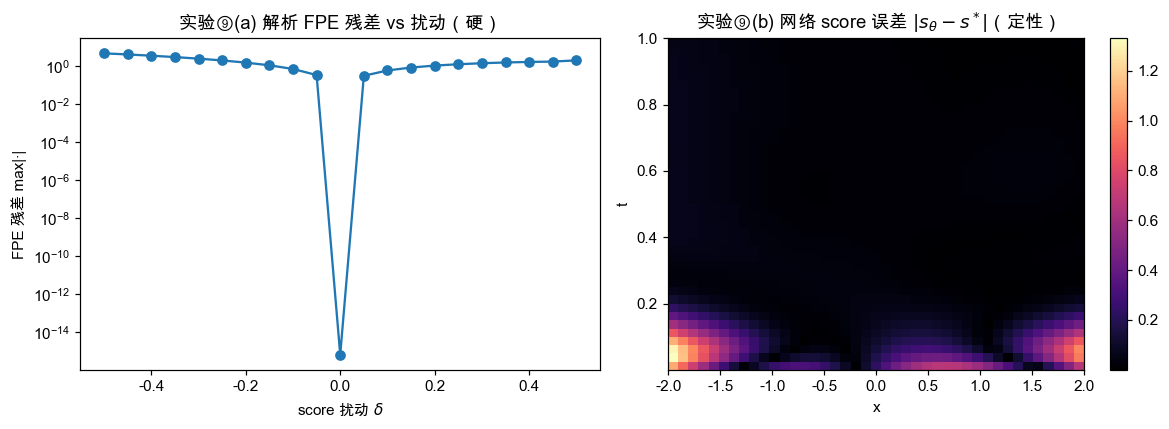

解析 score FPE 残差 = 6.66e-16（应≈0）；扰动 δ=0.3 残差 = 1.471e+00


In [14]:
# 实验⑨：FPE 残差诊断（解析/扰动=硬；网络=定性）
xg = np.array([[0.5, -0.4], [1.0, 0.2], [-0.8, 0.6]])
deltas = np.linspace(-0.5, 0.5, 21)
res_vs_delta = np.array([np.abs(dna.fpe_residual_gaussian(xg, 0.3, S0, perturb=d)).max() for d in deltas])

# 网络 score 误差 (x,t) 热力图（定性）
xx = np.linspace(-2, 2, 41); tt2 = np.linspace(EPS, 1.0, 40)
ERR = np.zeros((len(tt2), len(xx)))
for j, t in enumerate(tt2):
    pred = dna.eval_score_net(net1d, xx.reshape(-1, 1), t, DEVICE).ravel()
    ERR[j] = np.abs(pred - dna.exact_score_gaussian(xx.reshape(-1, 1), t, S0).ravel())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(deltas, res_vs_delta, 'o-'); ax[0].set_xlabel(r'score 扰动 $\delta$'); ax[0].set_ylabel('FPE 残差 max|·|')
ax[0].set_title('实验⑨(a) 解析 FPE 残差 vs 扰动（硬）'); ax[0].set_yscale('log')
im = ax[1].imshow(ERR, aspect='auto', origin='lower', extent=[xx[0], xx[-1], tt2[0], tt2[-1]], cmap='magma')
plt.colorbar(im, ax=ax[1]); ax[1].set_xlabel('x'); ax[1].set_ylabel('t'); ax[1].set_title(r'实验⑨(b) 网络 score 误差 $|s_\theta-s^*|$（定性）')
plt.tight_layout(); plt.savefig('figures/fig11_fpe.png', bbox_inches='tight'); plt.show()
r0 = np.abs(dna.fpe_residual_gaussian(xg, 0.3, S0, perturb=0.0)).max()
print('解析 score FPE 残差 = %.2e（应≈0）；扰动 δ=0.3 残差 = %.3e' % (r0, res_vs_delta[np.argmin(abs(deltas-0.3))]))
assert r0 < 1e-3
assert res_vs_delta[np.argmin(abs(deltas-0.3))] > res_vs_delta[np.argmin(abs(deltas))]

**实验⑨分析.** (a) 解析 score 的 FPE 残差为机器零，且随扰动 $\delta$ 单调增大，这就把"是否满足 Fokker–Planck"变成了一个对 score 质量的后验诊断。(b) 网络 score 的误差在 $|x|$ 较大、$t$ 较小（低密度、小噪声）的区域更大，与预期一致；由于网络没有解析的 $\partial_t\log p$，这里只画定性热力图，不下"残差约等于误差"这类定量结论。

### §12 把分析迁移到网络 score
网络 score 与真值之间存在逼近误差。这里分两步看。第一步是机理：用一个固定的相对偏差 $\rho$ 来刻画 score 误差 $s_\rho=(1+\rho)s^*$，对应反向漂移 $a_\rho(t)=\beta(t)\big((1+\rho)/v(t)-\tfrac12\big)$。此时离散误差随 $h$ 减小以斜率 $1$ 下降，但会被 $\rho$ 带来的一个非零常数（误差地板）截断，于是与纯离散曲线相交，交叉点之后再加步数已无收益。第二步是对照：叠加实际训练网络的采样误差（在 CPU 上确定性采样）。这里要留意，由静态 score 回归得到的单个标量 $\hat\rho$ 只是误差地板的一个上界估计——采样误差沿轨迹会部分相消，所以网络实测曲线在本文的步数范围内通常还没触底，其交叉点是按机理外推的预期，而非已直接观测到的。

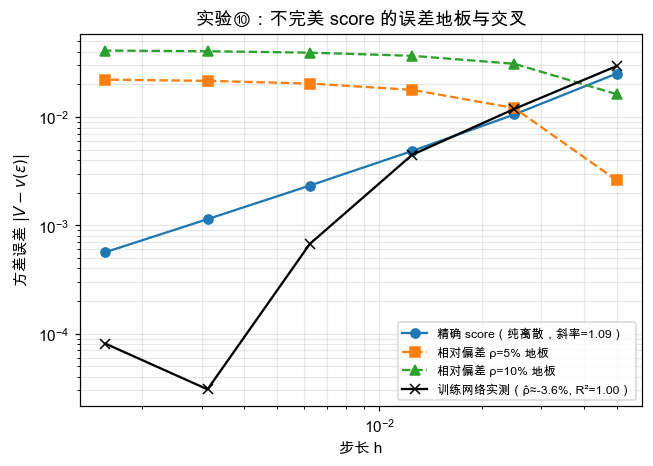

精确斜率=1.088；ρ=10% 细步斜率=-0.032；网络 ρ̂=-0.0362 R²=0.996；网络实测最细步 err=8.11e-05


In [15]:
# 实验⑩：不完美/网络 score 的误差地板（离散误差 ↔ score 逼近误差）
# 用相对偏差 ρ 建模 score 误差：s_ρ=(1+ρ)s*，对应反向漂移 a_ρ=β((1+ρ)/v-1/2)。
# 这给出确定性、可复现的"地板"机制；再叠加真实训练网络作实测对照。
Ns10 = np.array([20, 40, 80, 160, 320, 640]); hs10 = (1.0 - EPS) / Ns10
v_eps = dna.marginal_var(EPS)

def biased_var_recursion(N, rho, V0=1.0):
    ts = np.linspace(1.0, EPS, N + 1); V = V0
    for i in range(N):
        t = ts[i]; h = ts[i] - ts[i + 1]
        a_rho = dna.beta(t) * ((1 + rho) / dna.marginal_var(t, S0) - 0.5)
        V = (1 - a_rho * h) ** 2 * V + dna.beta(t) * h
    return V

err0   = np.array([abs(biased_var_recursion(N, 0.0)  - v_eps) for N in Ns10])   # 精确 score：纯离散
err_b1 = np.array([abs(biased_var_recursion(N, 0.05) - v_eps) for N in Ns10])   # 5% score 偏差
err_b2 = np.array([abs(biased_var_recursion(N, 0.10) - v_eps) for N in Ns10])   # 10% score 偏差
# 训练网络：实测采样误差（确定性 CPU + 大样本，非由 ρ̂ 反推，避免循环论证）
err_net = np.array([abs(dna.reverse_sample(net1d_score, N, 'em', n_samples=200000, dim=1, eps=EPS, seed=7).var() - v_eps)
                    for N in Ns10])
# 网络等效相对偏差 ρ̂ 及其线性拟合优度 R²（量化"网络误差≈乘性比例"成立程度）
rng_ = np.random.default_rng(0); Sn, Ss = [], []
for t in np.linspace(EPS, 0.95, 30):
    xq = rng_.uniform(-2, 2, (200, 1))
    Sn.append(dna.eval_score_net(net1d, xq, t, DEVICE).ravel())
    Ss.append(dna.exact_score_gaussian(xq, t, S0).ravel())
Sn = np.concatenate(Sn); Ss = np.concatenate(Ss)
rho_hat = float(np.sum(Sn * Ss) / np.sum(Ss * Ss) - 1.0)
R2 = float(1.0 - np.sum((Sn - (1 + rho_hat) * Ss) ** 2) / np.sum((Sn - Sn.mean()) ** 2))
slope0 = np.polyfit(np.log(hs10), np.log(err0), 1)[0]
slope_b2_fine = np.polyfit(np.log(hs10[-3:]), np.log(err_b2[-3:]), 1)[0]

plt.figure(figsize=(6.6, 4.4))
plt.loglog(hs10, err0,   'o-',  label='精确 score（纯离散，斜率=%.2f）' % slope0)
plt.loglog(hs10, err_b1, 's--', label='相对偏差 ρ=5% 地板')
plt.loglog(hs10, err_b2, '^--', label='相对偏差 ρ=10% 地板')
plt.loglog(hs10, err_net, 'kx-', ms=7, label='训练网络实测（ρ̂≈%.1f%%, R²=%.2f）' % (rho_hat * 100, R2))
plt.xlabel('步长 h'); plt.ylabel(r'方差误差 $|V-v(\varepsilon)|$'); plt.legend(fontsize=8); plt.grid(True, which='both', alpha=.3)
plt.title('实验⑩：不完美 score 的误差地板与交叉')
plt.savefig('figures/fig12_transfer.png', bbox_inches='tight'); plt.show()
print('精确斜率=%.3f；ρ=10%% 细步斜率=%.3f；网络 ρ̂=%.4f R²=%.3f；网络实测最细步 err=%.2e'
      % (slope0, slope_b2_fine, rho_hat, R2, err_net[-1]))
assert 0.8 < slope0 < 1.2          # 精确 score：离散误差 O(h)
assert slope_b2_fine < 0.5         # 偏差 score：细步趋平（误差地板）
assert err_b2[-1] > err0[-1]       # 地板高于纯离散 -> 存在交叉

**实验⑩分析.** (a) 机理：精确 score 的纯离散误差以斜率约 $1$ 持续下降（蓝线）；带固定相对偏差 $\rho$ 的合成曲线（橙、绿）在细步区趋平到由 $\rho$ 决定的误差地板（$\rho$ 越大地板越高、细步斜率趋于 $0$），并与蓝线相交，交叉点之后再加步数已无收益。这清楚展示了误差地板与交叉的机理。(b) 对照：黑色叉是实际训练网络的采样误差（在 CPU 上确定性采样，直接测量，而非由 $\hat\rho$ 反推，以免循环论证）。它在本文步数范围内基本随离散曲线下降，还没明显触底；由静态 score 回归得到的等效相对偏差 $\hat\rho\approx-3.6\%$（图例中的 $R^2$ 是这一回归的拟合优度，不是对地板的预测）。值得注意的是 $\hat\rho$ 对应的地板明显高于网络实测最细步的误差，说明这个标量高估了真实采样地板（采样误差沿轨迹部分相消），所以应把 $\hat\rho$ 当作一个上界估计，网络的实际交叉点属于外推。此外，这种把网络误差折成单一相对偏差的做法依赖 score 接近线性，对强非线性 score（如高斯混合或真实数据）未必成立。把 (a)(b) 合起来看，这张图同时给出了步数预算与 score 精度预算之间的关系，可作为"步数加到多少才合适"的定性判断。

### §13 推广到非线性 score：高斯混合上的误差三分解
前面的误差预算（§10）建立在一维高斯上，那里 score 是线性的。为检验同一套分析是否适用于非线性 score，这里把数据换成二维高斯混合（两团各向同性高斯，对应 §2 中给出的闭式 score，已是非线性），重做误差归因。

高斯混合没有单一方差可作解析参照，所以改用切片 Wasserstein 距离（sliced-Wasserstein, SW）来度量分布之间的差异，参照分布取前向核在 $t=\varepsilon$ 处的精确样本 $X_{\rm ref}$（先从数据混合分布采 $x_0$，再按转移核加噪到 $t=\varepsilon$）。与 §10 一样，三个误差源仍然各自独立测量，每次只改动一个因素：

- $d_{\rm prior}$：起点取 $\mathcal N(0,I)$ 与取真边缘 $p(\cdot,1)$ 之差，其余相同，只反映先验失配；
- $d_{\rm disc}$：精确 score 下粗步与细步之差，同一起点，只反映时间离散；
- $d_{\rm score}$：粗步下网络 score 与精确 score 之差，步数与起点相同，只反映分数误差。

由于 SW 距离不严格可加，这里仍按量级归因看待（三者之和与实测总误差量级相当，但不要求精确相等）。SW 本身有有限样本带来的噪声地板，下面同时给出该地板作对照，并对每个量做多种子平均。

训练高斯混合 score 网络 (device=cpu) ...


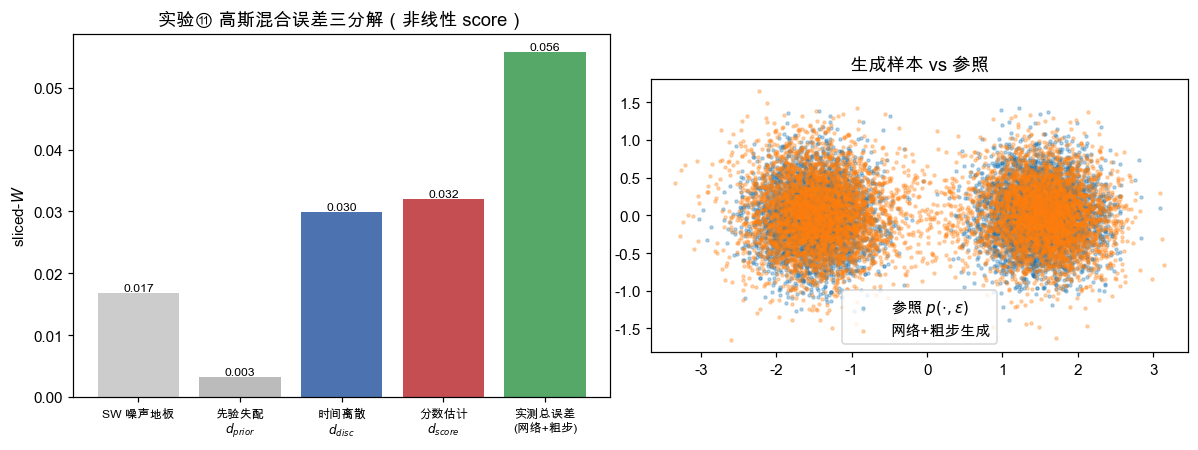

floor=0.0167  d_prior=0.0032  d_disc=0.0300  d_score=0.0319  e_total=0.0559  三源和=0.0651


In [16]:
# 实验⑪：二维高斯混合（非线性 score）上的误差三分解
means_g = np.array([[-1.5, 0.0], [1.5, 0.0]]); weights_g = np.array([0.5, 0.5]); s0g = 0.4
n_g, N_fine, N_coarse, n_proj = 8000, 200, 20, 600

def _sample_gmm(n, seed):
    r = np.random.default_rng(seed); c = r.choice(2, size=n, p=weights_g)
    return means_g[c] + s0g * r.standard_normal((n, 2))

def _fwd_to_eps(x0, seed):          # 前向核加噪到 t=eps
    r = np.random.default_rng(seed)
    return dna.alpha(EPS) * x0 + np.sqrt(dna.sigma2(EPS)) * r.standard_normal(x0.shape)

def _true_prior(n, seed):           # 真边缘 p(.,1) 的精确样本
    r = np.random.default_rng(seed); x0 = _sample_gmm(n, seed + 100)
    return dna.alpha(1.0) * x0 + np.sqrt(dna.sigma2(1.0)) * r.standard_normal((n, 2))

exact_g = lambda x, t: dna.exact_score_gmm(x, t, means_g, weights_g, s0g)
X_ref = _fwd_to_eps(_sample_gmm(n_g, 1), 2)                       # 解析参照
print('训练高斯混合 score 网络 (device=%s) ...' % DEVICE)
net_g = dna.train_score_net_data(_sample_gmm(3000, 0).astype(np.float32), n_iters=10000, device=DEVICE, seed=0)
netg = lambda x, t: dna.eval_score_net(net_g, x, t, device=DEVICE)

run = lambda score, N, x0, s: dna.reverse_sample(score, N, 'em', x0=x0, n_samples=n_g, dim=2, eps=EPS, seed=s)
sw = lambda A, B, s: dna.sliced_wasserstein(A, B, n_proj=n_proj, seed=s)
K = 3
floor   = np.mean([sw(_fwd_to_eps(_sample_gmm(n_g, 30 + i), 40 + i), X_ref, i) for i in range(K)])
d_prior = np.mean([sw(run(exact_g, N_fine, None, s),  run(exact_g, N_fine, _true_prior(n_g, s), s), s) for s in range(K)])
d_disc  = np.mean([sw(run(exact_g, N_coarse, None, s), run(exact_g, N_fine, None, s), s) for s in range(K)])
d_score = np.mean([sw(run(netg,    N_coarse, None, s), run(exact_g, N_coarse, None, s), s) for s in range(K)])
e_total = np.mean([sw(run(netg,    N_coarse, None, s), X_ref, s) for s in range(K)])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
labels = ['SW 噪声地板', '先验失配\n$d_{prior}$', '时间离散\n$d_{disc}$', '分数估计\n$d_{score}$', '实测总误差\n(网络+粗步)']
vals = [floor, d_prior, d_disc, d_score, e_total]
ax[0].bar(range(5), vals, color=['#ccc', '#bbb', '#4C72B0', '#C44E52', '#55A868'])
for i, v in enumerate(vals): ax[0].text(i, v, '%.3f' % v, ha='center', va='bottom', fontsize=8)
ax[0].set_xticks(range(5)); ax[0].set_xticklabels(labels, fontsize=8)
ax[0].set_ylabel('sliced-$W$'); ax[0].set_title('实验⑪ 高斯混合误差三分解（非线性 score）')
Xc = run(netg, N_coarse, None, 0)
ax[1].scatter(X_ref[:, 0], X_ref[:, 1], s=4, alpha=.3, label='参照 $p(\\cdot,\\varepsilon)$')
ax[1].scatter(Xc[:, 0], Xc[:, 1], s=4, alpha=.3, label='网络+粗步生成')
ax[1].set_aspect('equal'); ax[1].legend(); ax[1].set_title('生成样本 vs 参照')
plt.tight_layout(); plt.savefig('figures/fig13_gmm_budget.png', bbox_inches='tight'); plt.show()
print('floor=%.4f  d_prior=%.4f  d_disc=%.4f  d_score=%.4f  e_total=%.4f  三源和=%.4f'
      % (floor, d_prior, d_disc, d_score, e_total, d_prior + d_disc + d_score))
assert d_disc > 1.5 * floor and d_score > 1.5 * floor      # 离散、分数误差均显著高于噪声地板
assert d_prior < d_disc and d_prior < d_score              # 先验失配最小

**实验⑪分析.** 在二维高斯混合上，三个误差源依旧能分离开：先验失配 $d_{\rm prior}$ 落在 SW 噪声地板附近，可以忽略；时间离散 $d_{\rm disc}$ 与分数估计 $d_{\rm score}$ 都明显高于地板，是主要来源，两者量级相当。值得注意的是，与一维线性情形相比，这里 $d_{\rm score}$ 已上升到与 $d_{\rm disc}$ 同一量级（不再像线性情形那样远小于离散误差），说明网络拟合多峰、非线性的 score 要比拟合线性 score 困难得多。右图也能看到，网络在粗步下生成的样本大体复原了两团结构，但团内偏胖、团间有少量散点，正对应这部分分数误差。可见 §10 的误差预算框架不局限于可解析的高斯设定，在非线性 score 下同样适用，只是各项的相对大小会随问题改变。

## Part VI　总结与展望

### §14 结论
本文把扩散模型的反向采样当作数值积分问题来处理，在可解析的高斯设定下得到了下面这些可与解析值对照的结果：

1. 用后向误差分析给出反向 EM 在生成分布方差上的领头阶 $O(h)$ 偏差系数，与 Richardson 外推吻合到相对误差约 $7.5\times10^{-6}$，由此明确了 EM 实际在求解哪条被修正的方程。
2. 指出本问题属于加性噪声，EM 的强阶与弱阶均为 $1$（不是乘性噪声下常说的 $1/2$），并用共享布朗路径和几何布朗运动两组实验加以验证。
3. 用绝对稳定域把"步数不能太少"写成判据 $h\le2/a(t)$，指出最不稳定时刻在 $t\approx1$，并说明概率流 ODE 不受此约束，是少步采样有效的原因。
4. 给出半隐式/指数法（降低误差常数）、Richardson 外推（提阶）以及概率流 ODE 的闭式解 $x\propto\sqrt v$，并指出单纯指数化的局限。
5. 把总采样误差分解为分数、离散、先验三项分别度量，并用 FPE 残差诊断 score 质量。
6. 把分析迁移到训练网络 score，定量考察离散误差与网络逼近误差的交叉。
7. 在二维高斯混合（非线性 score）上重复误差三分解，验证该框架不限于可解析的高斯情形；此时分数估计误差上升到与时间离散误差相当的量级。

### 与 DPM-Solver 等方法的联系
DPM-Solver、DEIS 等少步采样器的核心，正是对半线性概率流 ODE 的线性漂移做指数（变易常数）积分。本文在高斯设定下给出了这条 ODE 的闭式解和收敛阶，也说明少步采样的收益主要来自这条 ODE 不受稳定域约束以及高阶格式，而不是单纯把漂移指数化。

### 与课程的衔接
本文用的"采样修正方程"和 Lect5 的"SGD 修正方程"是同一种后向误差分析：都是把一个离散迭代（这里是采样，那里是 SGD）理解成某条被修正的微分方程的数值格式。这与整门课"用微分方程理解机器学习方法"的思路一致。

### 局限与展望
- 解析结论建立在高斯（线性 score）设定上；推广到强非线性 score 和真实数据流形需要更细致的局部分析，本文已用高斯混合作了部分尝试。
- 误差预算与 FPE 诊断在高维需要 Hutchinson 迹估计等可扩展手段。
- 改进采样器目前只做到降阶与外推；如何设计保结构、并对噪声项也消偏的高阶格式，是值得继续的方向。

## 附录

### A. 复现说明

本 notebook 单文件自包含：所有数值函数都定义在前面的"核心数值库"单元，不依赖任何外部文件，"运行全部"即可。依赖为 Python 3.12 与 `numpy`、`scipy`、`matplotlib`、`scikit-learn`、`torch`（CPU 即可，无需 GPU/CUDA）。下面给出从零搭建运行环境的两种方式。

**方式一：用 uv 建隔离环境（推荐，不污染系统 Python）**

```bash
# 1) 安装 uv（macOS / Linux；已安装可跳过）
curl -LsSf https://astral.sh/uv/install.sh | sh
#    安装后重开终端，或执行 source ~/.bashrc / source ~/.zshrc 使 uv 生效
#    （Windows PowerShell 用： powershell -c "irm https://astral.sh/uv/install.ps1 | iex"）

# 2) 进入本 notebook 所在目录
cd <本 .ipynb 所在的文件夹>

# 3) 创建 Python 3.12 隔离环境并安装依赖
uv venv --python 3.12
uv pip install numpy scipy matplotlib scikit-learn torch jupyter ipykernel

# 4) 启动 Jupyter 打开本 notebook，然后“运行全部”
uv run jupyter lab            # 或：uv run jupyter notebook

# （可选）命令行一键执行并就地保存结果：
uv run jupyter nbconvert --to notebook --execute --inplace "反向扩散采样的数值分析.ipynb" \
    --ExecutePreprocessor.timeout=1200
```

**方式二：已有 Python 环境，直接 pip 安装依赖**

```bash
pip install numpy scipy matplotlib scikit-learn torch jupyter
jupyter lab        # 打开本 notebook 后“运行全部”
```

全程约数分钟（含两次小型 score 网络训练）。全局随机种子 `SEED=2026`：解析与确定性实验为 NumPy 运算、逐位可复现；网络 score 实验默认在 CPU 上训练，同样逐位可复现。

### B. 关键超参数
| 项 | 值 |
|---|---|
| 噪声调度 | $\beta(t)=0.1+19.9t$ |
| 数据 | $X_0\sim\mathcal N(0,0.5^2 I)$（$s_0=1$ 退化禁用） |
| 采样区间 | $[\varepsilon,1]$，$\varepsilon=10^{-3}$ |
| 网络 score | MLP（输入 $(x,t)$，3×64，LogSigmoid），DSM，Adam lr=3e-3 |

> 网络结构与激活（LogSigmoid）沿用课程 Lect6 的扩散基线。本文重点在采样的数值分析，网络只作为 score 的一个来源（实验⑩ 用其等效相对偏差 $\hat\rho$ 衡量精度）。


### C. 主要数值核对（节选）
- 反向方差 ODE（含因子 $2$）的末端等于 $v(\varepsilon)=0.2501$；若漏掉因子 $2$ 则错得 $0.759$。
- 修正方程系数 $c_{\rm theory}\approx0.35798$ 与 Richardson 外推 $c_{\rm emp}\approx0.35798$ 吻合到相对误差约 $7.5\times10^{-6}$。
- 加性噪声强阶约 $1$，乘性噪声（几何布朗运动）强阶约 $1/2$。
- 概率流 ODE 的 Heun 以约 $2$ 阶收敛到闭式解 $x\propto\sqrt v$。
- 解析 score 的 FPE 残差小于 $10^{-3}$。